In [ ]:
import os

os.makedirs('/root/.kaggle', exist_ok=True)

with open('/root/.kaggle/kaggle.json', 'w') as f:
    f.write('{"username":"sarahjahangir","key":"1365c6f3ea54ebb76d730846768637ac"}')

os.chmod('/root/.kaggle/kaggle.json', 0o600)
print("✅ Kaggle API Ready!")

✅ Kaggle API Ready!


In [ ]:
!kaggle datasets download -d marquis03/plants-classification
print("✅ Downloaded!")

Dataset URL: https://www.kaggle.com/datasets/marquis03/plants-classification
License(s): apache-2.0
100% 1.34G/1.34G [00:18<00:00, 77.1MB/s]

✅ Downloaded!


In [ ]:
import os

# Check if zip file exists
files = os.listdir('/content')
print("Files in Colab:", files)

Files in Colab: ['.config', 'plants-classification.zip', 'sample_data']


In [ ]:
!unzip -q plants-classification.zip -d plant_dataset
print("✅ Unzipped!")

✅ Unzipped!


In [ ]:
import os

folders = os.listdir('plant_dataset')
print("Folders found:", folders)

Folders found: ['test', 'train', 'test.csv', 'val.csv', 'train.csv', 'val']


In [ ]:
import os

# See how many plant classes we have
train_folders = os.listdir('plant_dataset/train')
print("Total plant classes:", len(train_folders))
print("\nPlant names:")
for plant in train_folders:
    print("-", plant)

Total plant classes: 31

Plant names:
- guava
- coconut
- galangal
- corn
- orange
- ginger
- tobacco
- sweetpotatoes
- classname.txt
- soybeans
- papaya
- paddy
- aloevera
- cucumber
- melon
- bilimbi
- eggplant
- mango
- shallot
- watermelon
- pomelo
- waterapple
- spinach
- cassava
- peperchili
- pineapple
- curcuma
- banana
- cantaloupe
- kale
- longbeans


In [ ]:
import os

# Check everything in main Colab folder
print("Everything in Colab:")
for item in os.listdir('/content'):
    print("-", item)

Everything in Colab:
- .config
- sample_data


In [ ]:
import os

# Step 1: Setup Kaggle
os.makedirs('/root/.kaggle', exist_ok=True)
with open('/root/.kaggle/kaggle.json', 'w') as f:
    f.write('{"username":"sarahjahangir","key":"1365c6f3ea54ebb76d730846768637ac"}')
os.chmod('/root/.kaggle/kaggle.json', 0o600)
print("✅ Step 1: Kaggle Ready!")

# Step 2: Download dataset
os.system('kaggle datasets download -d marquis03/plants-classification')
print("✅ Step 2: Downloaded!")

# Step 3: Unzip
os.system('unzip -q plants-classification.zip -d /content/plant_dataset')
print("✅ Step 3: Unzipped!")

# Step 4: Check contents
print("\nFolders found:")
for item in os.listdir('/content/plant_dataset'):
    print("-", item)

✅ Step 1: Kaggle Ready!
✅ Step 2: Downloaded!
✅ Step 3: Unzipped!

Folders found:
- test
- train
- test.csv
- val.csv
- train.csv
- val


In [ ]:
import os

train_path = '/content/plant_dataset/train'
total = 0

for plant in os.listdir(train_path):
    plant_path = os.path.join(train_path, plant)
    if os.path.isdir(plant_path):
        count = len(os.listdir(plant_path))
        total += count
        print(f"{plant}: {count} images")

print(f"\n✅ Total training images: {total}")

guava: 700 images
coconut: 700 images
galangal: 700 images
corn: 700 images
orange: 700 images
ginger: 700 images
tobacco: 700 images
sweetpotatoes: 700 images
soybeans: 700 images
papaya: 700 images
paddy: 700 images
aloevera: 700 images
cucumber: 700 images
melon: 700 images
bilimbi: 700 images
eggplant: 700 images
mango: 700 images
shallot: 700 images
watermelon: 700 images
pomelo: 700 images
waterapple: 700 images
spinach: 700 images
cassava: 700 images
peperchili: 700 images
pineapple: 700 images
curcuma: 700 images
banana: 700 images
cantaloupe: 700 images
kale: 700 images
longbeans: 700 images

✅ Total training images: 21000


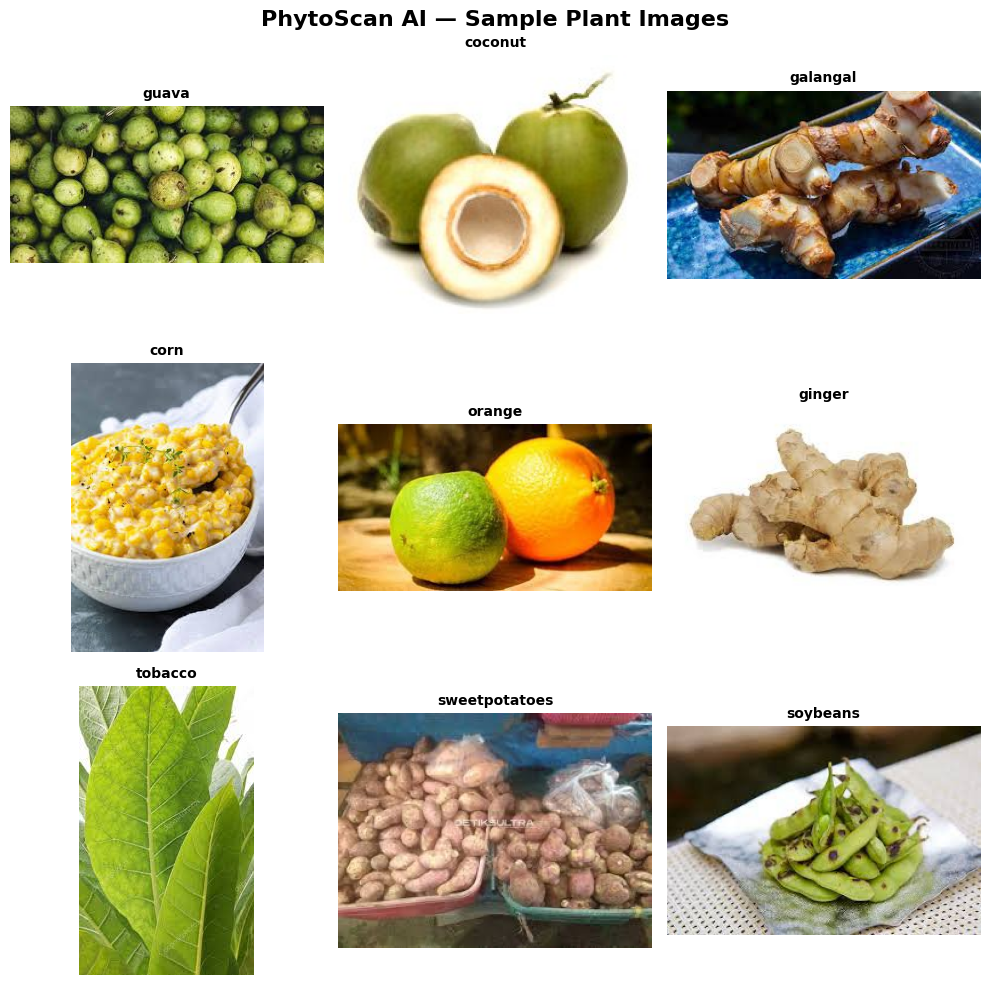

✅ Sample images displayed!


In [ ]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import os

train_path = '/content/plant_dataset/train'
plant_names = [p for p in os.listdir(train_path)
               if os.path.isdir(os.path.join(train_path, p))]

# Show one image from first 9 plants
fig, axes = plt.subplots(3, 3, figsize=(10, 10))
fig.suptitle('PhytoScan AI — Sample Plant Images',
             fontsize=16, fontweight='bold')

for i, ax in enumerate(axes.flat):
    plant = plant_names[i]
    plant_path = os.path.join(train_path, plant)
    img_name = os.listdir(plant_path)[0]
    img_path = os.path.join(plant_path, img_name)

    img = mpimg.imread(img_path)
    ax.imshow(img)
    ax.set_title(plant, fontsize=10, fontweight='bold')
    ax.axis('off')

plt.tight_layout()
plt.show()
print("✅ Sample images displayed!")

In [ ]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator

IMG_SIZE = 224
BATCH_SIZE = 32

# Prepare training data with augmentation
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    horizontal_flip=True,
    zoom_range=0.2,
    shear_range=0.2
)

# Prepare validation data
val_datagen = ImageDataGenerator(rescale=1./255)

# Load training images
train_data = train_datagen.flow_from_directory(
    '/content/plant_dataset/train',
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

# Load validation images
val_data = val_datagen.flow_from_directory(
    '/content/plant_dataset/val',
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

print("✅ Data Ready!")
print(f"Training images:   {train_data.samples}")
print(f"Validation images: {val_data.samples}")
print(f"Number of classes: {train_data.num_classes}")

Found 21000 images belonging to 30 classes.
Found 3000 images belonging to 30 classes.
✅ Data Ready!
Training images:   21000
Validation images: 3000
Number of classes: 30


In [ ]:
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras import layers, models

# Step 1: Load EfficientNet (pre-trained brain)
base_model = EfficientNetB0(
    weights='imagenet',
    include_top=False,
    input_shape=(224, 224, 3)
)

# Step 2: Freeze it first
base_model.trainable = False

# Step 3: Add our plant classification layers on top
model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.BatchNormalization(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(30, activation='softmax')
])

# Step 4: Compile
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("✅ Model Built Successfully!")
print(f"Total layers: {len(model.layers)}")
model.summary()

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
✅ Model Built Successfully!
Total layers: 6


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 1280)           │         5,120 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 30)             │         7,710 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,390,337 (16.75 MB)

 Trainable params: 338,206 (1.29 MB)

 Non-trainable params: 4,052,131 (15.46 MB)

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

# Stop training if no improvement
early_stop = EarlyStopping(
    monitor='val_accuracy',
    patience=3,
    restore_best_weights=True
)

# Save best model automatically
checkpoint = ModelCheckpoint(
    'best_model.h5',
    monitor='val_accuracy',
    save_best_only=True,
    verbose=1
)

print("🚀 Training Started!")
print("Watch accuracy increase each epoch...\n")

# Phase 1: Train only our layers
history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=10,
    callbacks=[early_stop, checkpoint],
    verbose=1
)

print("\n✅ Phase 1 Training Complete!")
print(f"Best Validation Accuracy: {max(history.history['val_accuracy'])*100:.2f}%")

🚀 Training Started!
Watch accuracy increase each epoch...

Epoch 1/10
657/657 ━━━━━━━━━━━━━━━━━━━━ 0s 455ms/step - accuracy: 0.0368 - loss: 3.7317
Epoch 1: val_accuracy improved from None to 0.03100, saving model to best_model.h5



Epoch 1: finished saving model to best_model.h5
657/657 ━━━━━━━━━━━━━━━━━━━━ 357s 498ms/step - accuracy: 0.0378 - loss: 3.5778 - val_accuracy: 0.0310 - val_loss: 3.3986
Epoch 2/10
657/657 ━━━━━━━━━━━━━━━━━━━━ 0s 429ms/step - accuracy: 0.0427 - loss: 3.3981
Epoch 2: val_accuracy improved from 0.03100 to 0.04333, saving model to best_model.h5



Epoch 2: finished saving model to best_model.h5
657/657 ━━━━━━━━━━━━━━━━━━━━ 293s 445ms/step - accuracy: 0.0423 - loss: 3.3900 - val_accuracy: 0.0433 - val_loss: 3.3676
Epoch 3/10
657/657 ━━━━━━━━━━━━━━━━━━━━ 0s 431ms/step - accuracy: 0.0446 - loss: 3.3695
Epoch 3: val_accuracy did not improve from 0.04333
657/657 ━━━━━━━━━━━━━━━━━━━━ 291s 444ms/step - accuracy: 0.0457 - loss: 3.3674 - val_accuracy: 0.0397 - val_loss: 3.3524
Epoch 4/10
657/657 ━━━━━━━━━━━━━━━━━━━━ 0s 427ms/step - accuracy: 0.0481 - loss: 3.3604
Epoch 4: val_accuracy improved from 0.04333 to 0.05400, saving model to best_model.h5



Epoch 4: finished saving model to best_model.h5
657/657 ━━━━━━━━━━━━━━━━━━━━ 290s 441ms/step - accuracy: 0.0495 - loss: 3.3579 - val_accuracy: 0.0540 - val_loss: 3.3357
Epoch 5/10
657/657 ━━━━━━━━━━━━━━━━━━━━ 0s 428ms/step - accuracy: 0.0512 - loss: 3.3507
Epoch 5: val_accuracy did not improve from 0.05400
657/657 ━━━━━━━━━━━━━━━━━━━━ 289s 441ms/step - accuracy: 0.0502 - loss: 3.3511 - val_accuracy: 0.0517 - val_loss: 3.3377
Epoch 6/10
657/657 ━━━━━━━━━━━━━━━━━━━━ 0s 431ms/step - accuracy: 0.0467 - loss: 3.3510
Epoch 6: val_accuracy improved from 0.05400 to 0.05833, saving model to best_model.h5



Epoch 6: finished saving model to best_model.h5
657/657 ━━━━━━━━━━━━━━━━━━━━ 292s 444ms/step - accuracy: 0.0481 - loss: 3.3495 - val_accuracy: 0.0583 - val_loss: 3.3248
Epoch 7/10
657/657 ━━━━━━━━━━━━━━━━━━━━ 0s 433ms/step - accuracy: 0.0532 - loss: 3.3437
Epoch 7: val_accuracy did not improve from 0.05833
657/657 ━━━━━━━━━━━━━━━━━━━━ 293s 445ms/step - accuracy: 0.0532 - loss: 3.3422 - val_accuracy: 0.0577 - val_loss: 3.3279
Epoch 8/10
657/657 ━━━━━━━━━━━━━━━━━━━━ 0s 419ms/step - accuracy: 0.0515 - loss: 3.3387
Epoch 8: val_accuracy did not improve from 0.05833
657/657 ━━━━━━━━━━━━━━━━━━━━ 286s 435ms/step - accuracy: 0.0540 - loss: 3.3378 - val_accuracy: 0.0463 - val_loss: 3.3444
Epoch 9/10
657/657 ━━━━━━━━━━━━━━━━━━━━ 0s 413ms/step - accuracy: 0.0521 - loss: 3.3377
Epoch 9: val_accuracy did not improve from 0.05833
657/657 ━━━━━━━━━━━━━━━━━━━━ 280s 426ms/step - accuracy: 0.0520 - loss: 3.3349 - val_accuracy: 0.0540 - val_loss: 3.3241

✅ Phase 1 Training Complete!
Best Validation Accu

In [ ]:
import tensorflow as tf
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

# Step 1: Rebuild model with unfrozen layers
base_model = EfficientNetB0(
    weights='imagenet',
    include_top=False,
    input_shape=(224, 224, 3)
)

# Unfreeze last 20 layers only
for layer in base_model.layers[:-20]:
    layer.trainable = False
for layer in base_model.layers[-20:]:
    layer.trainable = True

# Build model
model2 = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.BatchNormalization(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(30, activation='softmax')
])

# Step 2: Compile with lower learning rate
model2.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Step 3: Callbacks
early_stop = EarlyStopping(
    monitor='val_accuracy',
    patience=4,
    restore_best_weights=True,
    verbose=1
)

checkpoint = ModelCheckpoint(
    'best_model2.keras',
    monitor='val_accuracy',
    save_best_only=True,
    verbose=1
)

# Step 4: Train
print("🚀 Training Started!")
history2 = model2.fit(
    train_data,
    validation_data=val_data,
    epochs=15,
    callbacks=[early_stop, checkpoint],
    verbose=1
)

print("\n✅ Training Complete!")
print(f"Best Accuracy: {max(history2.history['val_accuracy'])*100:.2f}%")

🚀 Training Started!
Epoch 1/15
657/657 ━━━━━━━━━━━━━━━━━━━━ 0s 436ms/step - accuracy: 0.0360 - loss: 3.7668
Epoch 1: val_accuracy improved from None to 0.05133, saving model to best_model2.keras

Epoch 1: finished saving model to best_model2.keras
657/657 ━━━━━━━━━━━━━━━━━━━━ 334s 467ms/step - accuracy: 0.0390 - loss: 3.6456 - val_accuracy: 0.0513 - val_loss: 3.3987
Epoch 2/15
657/657 ━━━━━━━━━━━━━━━━━━━━ 0s 418ms/step - accuracy: 0.0385 - loss: 3.5210
Epoch 2: val_accuracy improved from 0.05133 to 0.05533, saving model to best_model2.keras

Epoch 2: finished saving model to best_model2.keras
657/657 ━━━━━━━━━━━━━━━━━━━━ 285s 434ms/step - accuracy: 0.0400 - loss: 3.5028 - val_accuracy: 0.0553 - val_loss: 3.3876
Epoch 3/15
657/657 ━━━━━━━━━━━━━━━━━━━━ 0s 425ms/step - accuracy: 0.0470 - loss: 3.4540
Epoch 3: val_accuracy did not improve from 0.05533
657/657 ━━━━━━━━━━━━━━━━━━━━ 288s 439ms/step - accuracy: 0.0455 - loss: 3.4460 - val_accuracy: 0.0500 - val_loss: 3.3992
Epoch 4/15
657/657 

Class labels:
{'aloevera': 0, 'banana': 1, 'bilimbi': 2, 'cantaloupe': 3, 'cassava': 4, 'coconut': 5, 'corn': 6, 'cucumber': 7, 'curcuma': 8, 'eggplant': 9, 'galangal': 10, 'ginger': 11, 'guava': 12, 'kale': 13, 'longbeans': 14, 'mango': 15, 'melon': 16, 'orange': 17, 'paddy': 18, 'papaya': 19, 'peperchili': 20, 'pineapple': 21, 'pomelo': 22, 'shallot': 23, 'soybeans': 24, 'spinach': 25, 'sweetpotatoes': 26, 'tobacco': 27, 'waterapple': 28, 'watermelon': 29}

Image batch shape: (32, 224, 224, 3)
Label batch shape: (32, 30)
Sample label: [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 1.]
Max pixel value: 1.000
Min pixel value: 0.000


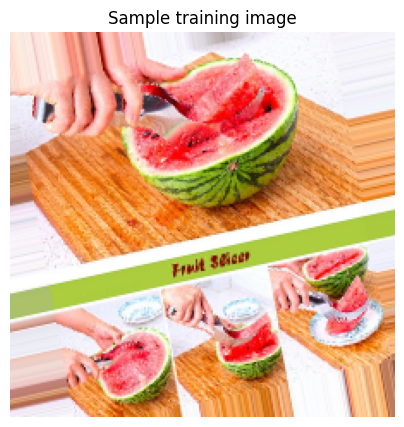

In [ ]:
import os
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

# Check class labels
print("Class labels:")
print(train_data.class_indices)

# Check one batch of data
images, labels = next(iter(train_data))
print(f"\nImage batch shape: {images.shape}")
print(f"Label batch shape: {labels.shape}")
print(f"Sample label: {labels[0]}")
print(f"Max pixel value: {images.max():.3f}")
print(f"Min pixel value: {images.min():.3f}")

# Show sample image
plt.figure(figsize=(5,5))
plt.imshow(images[0])
plt.title("Sample training image")
plt.axis('off')
plt.show()

In [ ]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator

IMG_SIZE = 224
BATCH_SIZE = 32

# EfficientNet does NOT want rescale=1./255
# It has its own built-in preprocessing!
train_datagen = ImageDataGenerator(
    rotation_range=20,
    horizontal_flip=True,
    zoom_range=0.2,
    shear_range=0.2,
    width_shift_range=0.2,
    height_shift_range=0.2,
    preprocessing_function=tf.keras.applications.efficientnet.preprocess_input
)

val_datagen = ImageDataGenerator(
    preprocessing_function=tf.keras.applications.efficientnet.preprocess_input
)

# Reload data
train_data = train_datagen.flow_from_directory(
    '/content/plant_dataset/train',
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

val_data = val_datagen.flow_from_directory(
    '/content/plant_dataset/val',
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

print("✅ Data reloaded with correct preprocessing!")
print(f"Training images:   {train_data.samples}")
print(f"Validation images: {val_data.samples}")

Found 21000 images belonging to 30 classes.
Found 3000 images belonging to 30 classes.
✅ Data reloaded with correct preprocessing!
Training images:   21000
Validation images: 3000


In [ ]:
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

# Rebuild model
base_model = EfficientNetB0(
    weights='imagenet',
    include_top=False,
    input_shape=(224, 224, 3)
)

# Unfreeze last 30 layers
for layer in base_model.layers[:-30]:
    layer.trainable = False
for layer in base_model.layers[-30:]:
    layer.trainable = True

model3 = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.BatchNormalization(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(30, activation='softmax')
])

model3.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

early_stop = EarlyStopping(
    monitor='val_accuracy',
    patience=5,
    restore_best_weights=True,
    verbose=1
)

checkpoint = ModelCheckpoint(
    'best_model3.keras',
    monitor='val_accuracy',
    save_best_only=True,
    verbose=1
)

print("Training Started!")
history3 = model3.fit(
    train_data,
    validation_data=val_data,
    epochs=15,
    callbacks=[early_stop, checkpoint],
    verbose=1
)

print("Training Complete!")
print(f"Best Accuracy: {max(history3.history['val_accuracy'])*100:.2f}%")

Training Started!
Epoch 1/15
657/657 ━━━━━━━━━━━━━━━━━━━━ 0s 446ms/step - accuracy: 0.3729 - loss: 2.4005
Epoch 1: val_accuracy improved from None to 0.81400, saving model to best_model3.keras

Epoch 1: finished saving model to best_model3.keras
657/657 ━━━━━━━━━━━━━━━━━━━━ 344s 478ms/step - accuracy: 0.5399 - loss: 1.6795 - val_accuracy: 0.8140 - val_loss: 0.5882
Epoch 2/15
657/657 ━━━━━━━━━━━━━━━━━━━━ 0s 424ms/step - accuracy: 0.7222 - loss: 0.9426
Epoch 2: val_accuracy improved from 0.81400 to 0.84400, saving model to best_model3.keras

Epoch 2: finished saving model to best_model3.keras
657/657 ━━━━━━━━━━━━━━━━━━━━ 288s 439ms/step - accuracy: 0.7359 - loss: 0.8826 - val_accuracy: 0.8440 - val_loss: 0.4663
Epoch 3/15
657/657 ━━━━━━━━━━━━━━━━━━━━ 0s 425ms/step - accuracy: 0.7844 - loss: 0.6920
Epoch 3: val_accuracy improved from 0.84400 to 0.86600, saving model to best_model3.keras

Epoch 3: finished saving model to best_model3.keras
657/657 ━━━━━━━━━━━━━━━━━━━━ 288s 438ms/step - acc

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import os
os.makedirs('/content/drive/MyDrive/PhytoScan', exist_ok=True)

# Save model
import shutil
shutil.copy('best_model3.keras',
            '/content/drive/MyDrive/PhytoScan/phytoscan_model.keras')

# Save class names
import json
class_names = train_data.class_indices
with open('/content/drive/MyDrive/PhytoScan/class_names.json', 'w') as f:
    json.dump(class_names, f)

print("Model saved to Google Drive!")
print("Class names saved!")

Mounted at /content/drive
Model saved to Google Drive!
Class names saved!


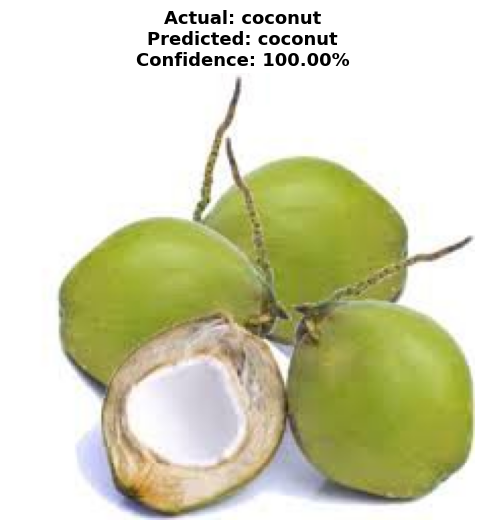

Actual Plant:     coconut
Predicted Plant:  coconut
Confidence:       100.00%
CORRECT PREDICTION!


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing import image
import json

# Load saved model and class names
model3 = load_model('/content/drive/MyDrive/PhytoScan/phytoscan_model.keras')

with open('/content/drive/MyDrive/PhytoScan/class_names.json') as f:
    class_indices = json.load(f)

# Flip dictionary — from number to name
class_names = {v: k for k, v in class_indices.items()}

# Pick a random test image automatically
import os
import random

test_path = '/content/plant_dataset/test'
random_plant = random.choice(os.listdir(test_path))
plant_folder = os.path.join(test_path, random_plant)
random_image = random.choice(os.listdir(plant_folder))
img_path = os.path.join(plant_folder, random_image)

# Predict
img = image.load_img(img_path, target_size=(224, 224))
img_array = image.img_to_array(img)
import tensorflow as tf
img_array = tf.keras.applications.efficientnet.preprocess_input(img_array)
img_array = np.expand_dims(img_array, axis=0)

predictions = model3.predict(img_array, verbose=0)
predicted_index = np.argmax(predictions)
predicted_plant = class_names[predicted_index]
confidence = np.max(predictions) * 100

# Show result
plt.figure(figsize=(6, 6))
plt.imshow(mpimg.imread(img_path))
plt.title(f"Actual: {random_plant}\nPredicted: {predicted_plant}\nConfidence: {confidence:.2f}%",
          fontsize=13, fontweight='bold')
plt.axis('off')
plt.show()

print(f"Actual Plant:     {random_plant}")
print(f"Predicted Plant:  {predicted_plant}")
print(f"Confidence:       {confidence:.2f}%")

if predicted_plant == random_plant:
    print("CORRECT PREDICTION!")
else:
    print("Wrong prediction this time.")

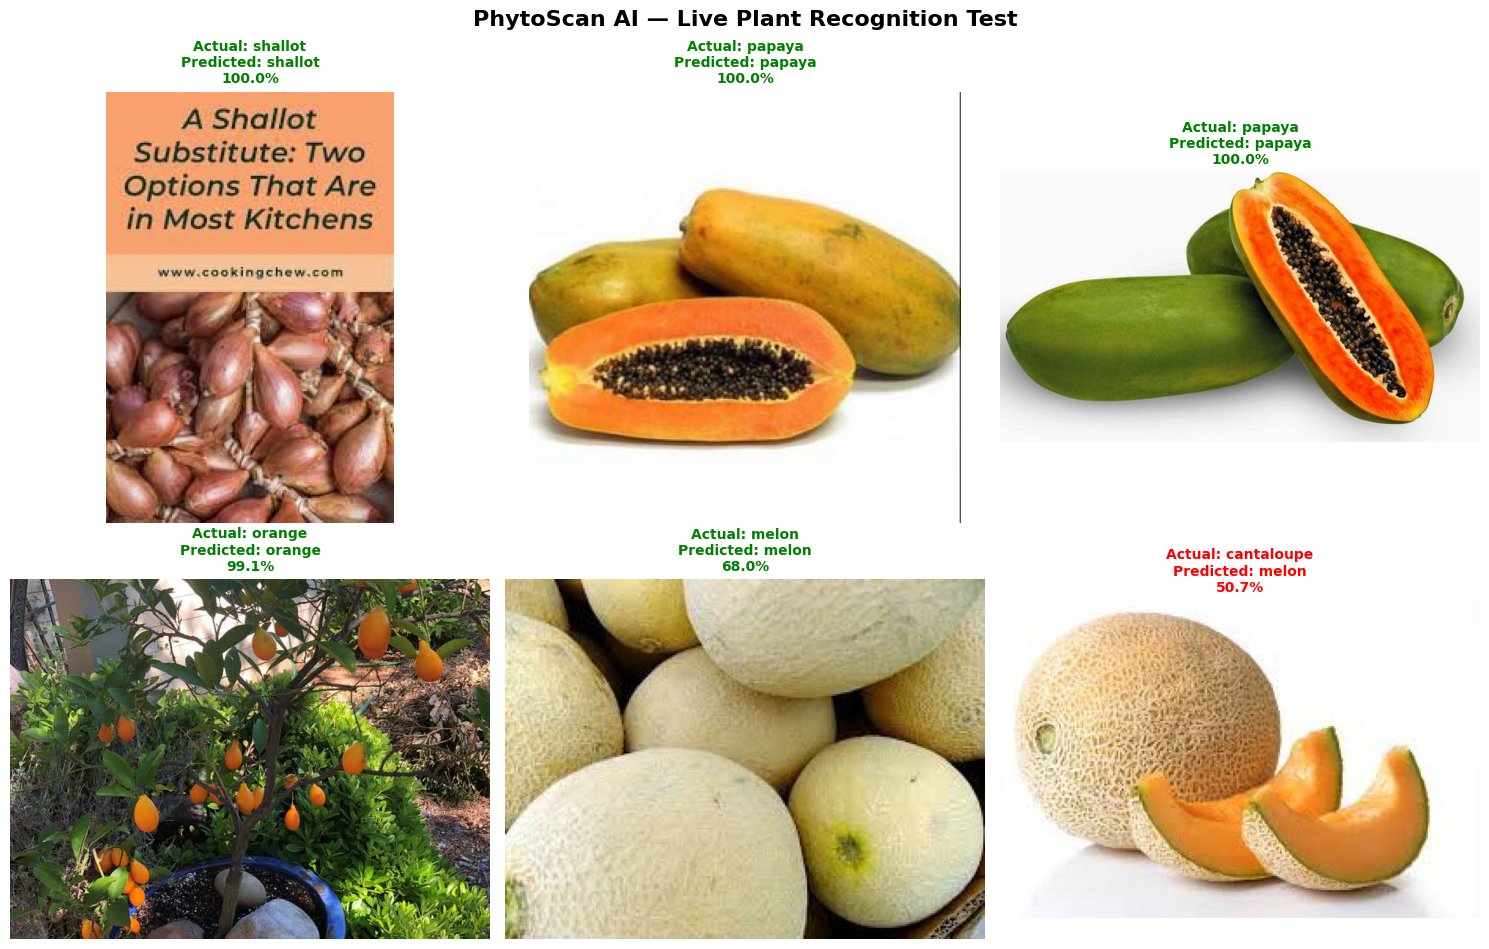

Score: 5/6 correct!
Accuracy on this test: 83%


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from tensorflow.keras.preprocessing import image
import tensorflow as tf
import os
import random

test_path = '/content/plant_dataset/test'
plants = os.listdir(test_path)

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
fig.suptitle('PhytoScan AI — Live Plant Recognition Test',
             fontsize=16, fontweight='bold')

correct = 0
total = 6

for i, ax in enumerate(axes.flat):
    # Pick random plant and image
    random_plant = random.choice(plants)
    plant_folder = os.path.join(test_path, random_plant)
    random_image = random.choice(os.listdir(plant_folder))
    img_path = os.path.join(plant_folder, random_image)

    # Predict
    img = image.load_img(img_path, target_size=(224, 224))
    img_array = image.img_to_array(img)
    img_array = tf.keras.applications.efficientnet.preprocess_input(img_array)
    img_array = np.expand_dims(img_array, axis=0)

    predictions = model3.predict(img_array, verbose=0)
    predicted_plant = class_names[np.argmax(predictions)]
    confidence = np.max(predictions) * 100

    # Show image
    ax.imshow(mpimg.imread(img_path))

    # Green title if correct, red if wrong
    color = 'green' if predicted_plant == random_plant else 'red'
    ax.set_title(
        f"Actual: {random_plant}\nPredicted: {predicted_plant}\n{confidence:.1f}%",
        fontsize=10, fontweight='bold', color=color
    )
    ax.axis('off')

    if predicted_plant == random_plant:
        correct += 1

plt.tight_layout()
plt.show()

print(f"Score: {correct}/{total} correct!")
print(f"Accuracy on this test: {correct/total*100:.0f}%")

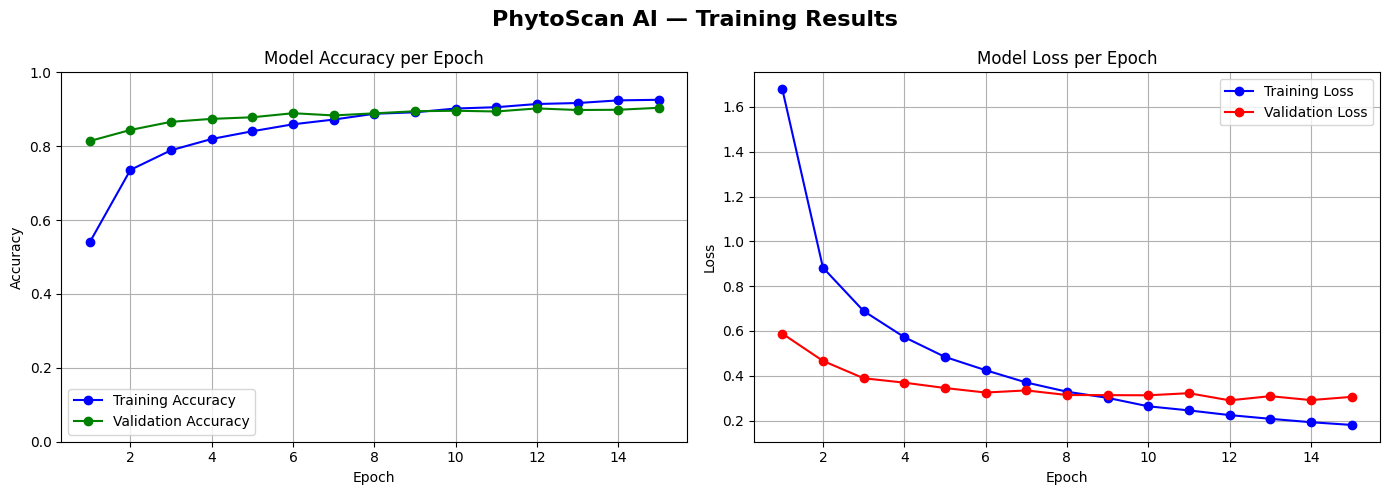

Graph saved to Google Drive!


In [ ]:
import matplotlib.pyplot as plt

# Get history data
train_acc = history3.history['accuracy']
val_acc   = history3.history['val_accuracy']
train_loss = history3.history['loss']
val_loss   = history3.history['val_accuracy']

epochs = range(1, len(train_acc) + 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('PhytoScan AI — Training Results',
             fontsize=16, fontweight='bold')

# Accuracy plot
axes[0].plot(epochs, train_acc, 'b-o', label='Training Accuracy')
axes[0].plot(epochs, val_acc,   'g-o', label='Validation Accuracy')
axes[0].set_title('Model Accuracy per Epoch')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(True)
axes[0].set_ylim([0, 1])

# Loss plot
axes[1].plot(epochs, history3.history['loss'],
             'b-o', label='Training Loss')
axes[1].plot(epochs, history3.history['val_loss'],
             'r-o', label='Validation Loss')
axes[1].set_title('Model Loss per Epoch')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/PhytoScan/training_results.png',
            dpi=150, bbox_inches='tight')
plt.show()

print("Graph saved to Google Drive!")

In [ ]:
import numpy as np
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import tensorflow as tf

# Load test data
test_datagen = ImageDataGenerator(
    preprocessing_function=tf.keras.applications.efficientnet.preprocess_input
)

test_data = test_datagen.flow_from_directory(
    '/content/plant_dataset/test',
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical',
    shuffle=False
)

# Get all predictions
print("Generating predictions on test set...")
predictions = model3.predict(test_data, verbose=1)
predicted_classes = np.argmax(predictions, axis=1)
true_classes = test_data.classes

print("Done!")
print(f"Total test images: {len(true_classes)}")

Found 6000 images belonging to 30 classes.
Generating predictions on test set...
188/188 ━━━━━━━━━━━━━━━━━━━━ 39s 160ms/step
Done!
Total test images: 6000


In [ ]:
from sklearn.metrics import classification_report

# Get class names in correct order
class_labels = list(test_data.class_indices.keys())

# Generate report
report = classification_report(
    true_classes,
    predicted_classes,
    target_names=class_labels
)

print("Classification Report:")
print("="*60)
print(report)

# Save report
with open('/content/drive/MyDrive/PhytoScan/classification_report.txt', 'w') as f:
    f.write(report)

print("Report saved to Google Drive!")

Classification Report:
               precision    recall  f1-score   support

     aloevera       0.98      0.94      0.96       200
       banana       0.99      0.92      0.95       200
      bilimbi       0.97      0.98      0.97       200
   cantaloupe       0.33      0.07      0.12       200
      cassava       0.96      0.94      0.95       200
      coconut       0.94      0.85      0.90       200
         corn       0.96      0.97      0.97       200
     cucumber       0.97      0.97      0.97       200
      curcuma       0.95      0.90      0.92       200
     eggplant       0.95      0.94      0.95       200
     galangal       0.82      0.97      0.89       200
       ginger       0.86      0.83      0.85       200
        guava       0.94      0.94      0.94       200
         kale       0.95      0.94      0.95       200
    longbeans       0.97      0.97      0.97       200
        mango       0.87      0.83      0.85       200
        melon       0.47      0.82      0

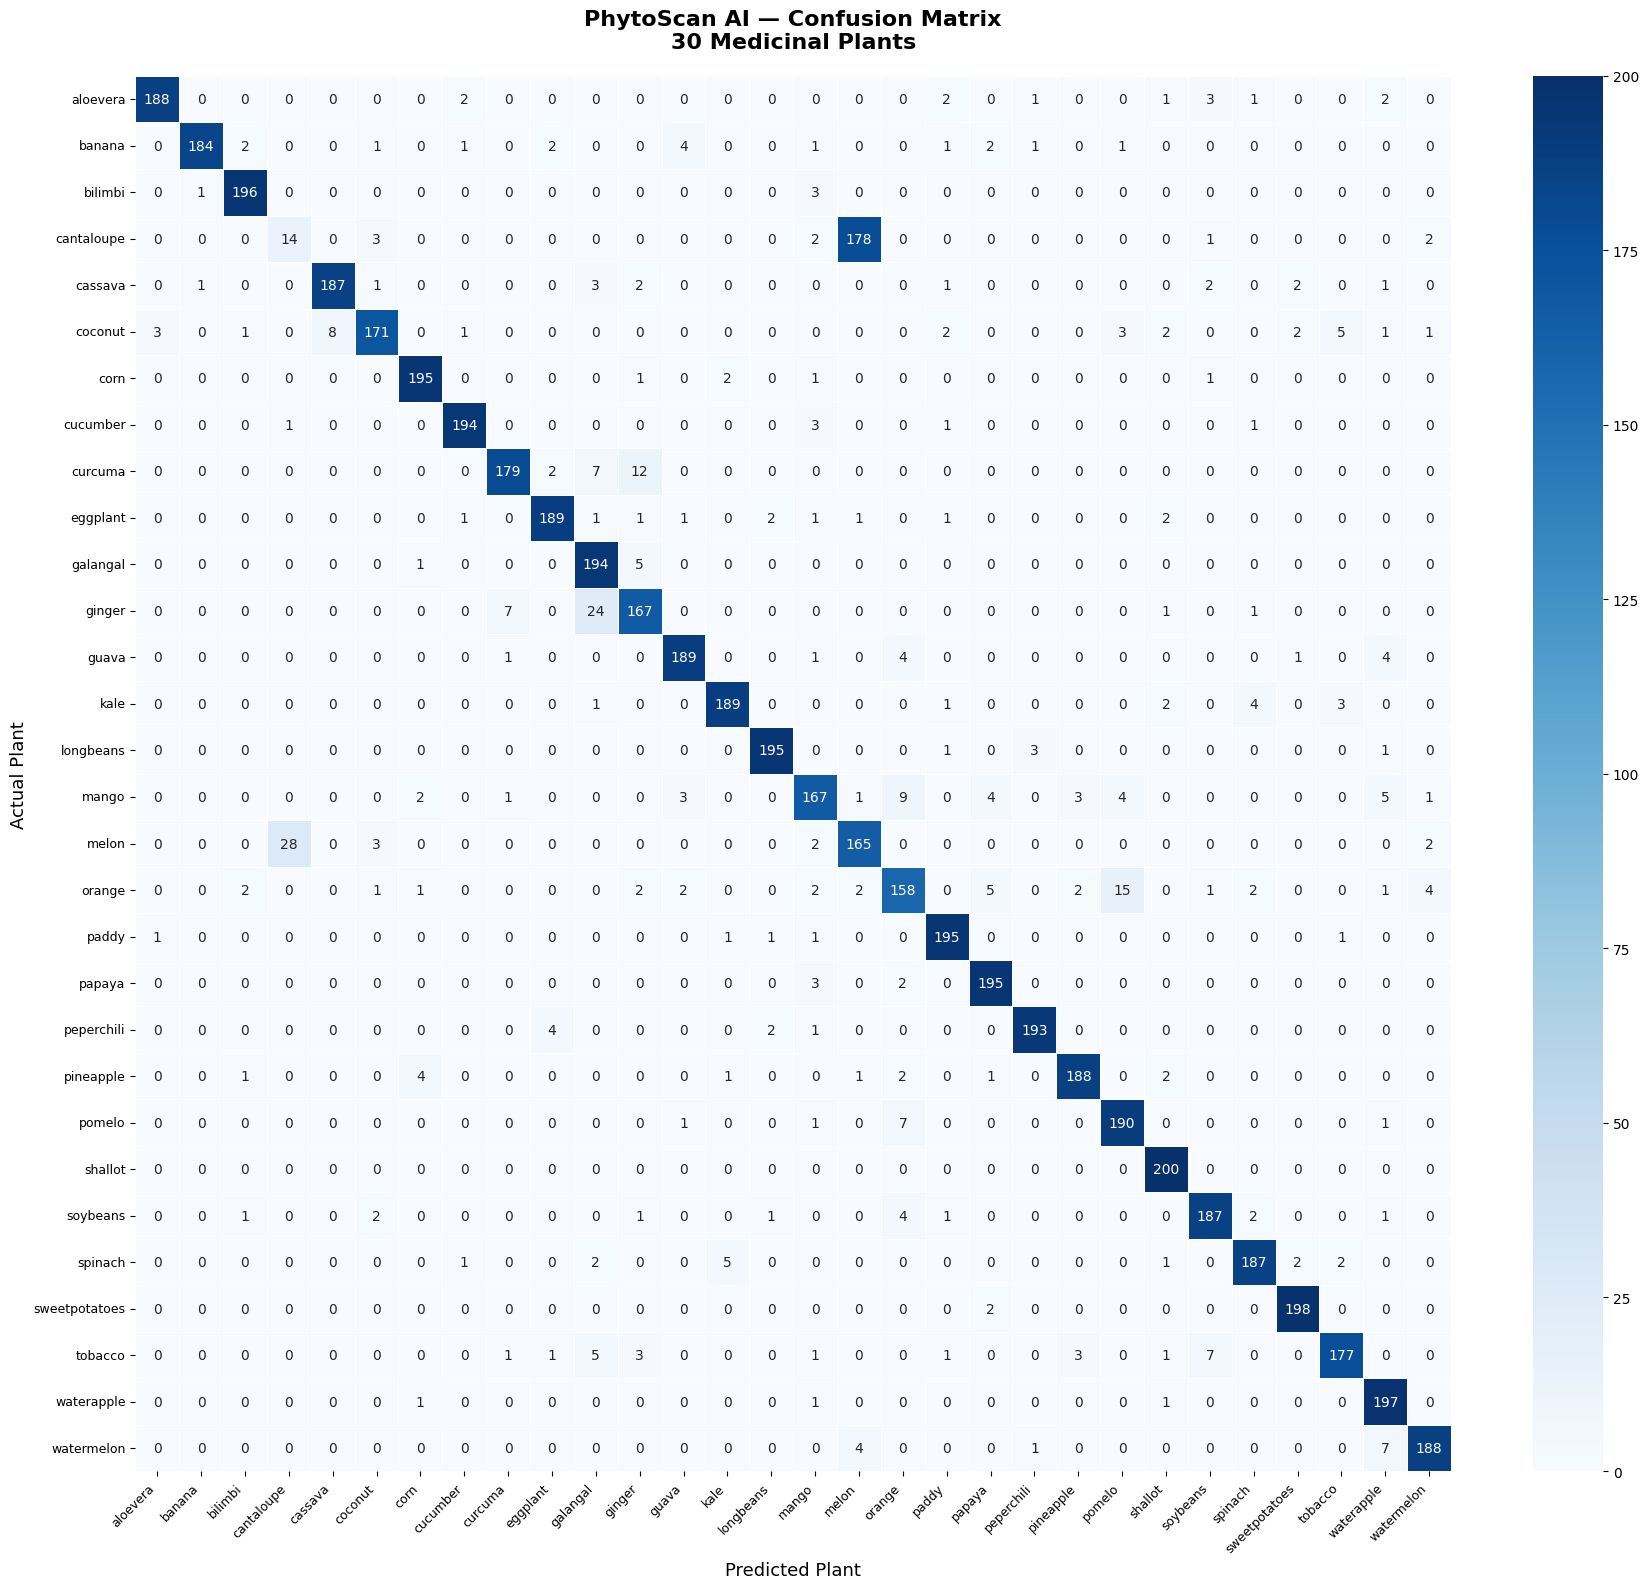

Confusion Matrix saved to Google Drive!


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
import numpy as np

# Generate confusion matrix
cm = confusion_matrix(true_classes, predicted_classes)

# Plot
plt.figure(figsize=(18, 16))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=class_labels,
    yticklabels=class_labels,
    linewidths=0.5
)

plt.title('PhytoScan AI — Confusion Matrix\n30 Medicinal Plants',
          fontsize=16, fontweight='bold', pad=20)
plt.ylabel('Actual Plant', fontsize=13)
plt.xlabel('Predicted Plant', fontsize=13)
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.yticks(rotation=0, fontsize=9)
plt.tight_layout()

plt.savefig('/content/drive/MyDrive/PhytoScan/confusion_matrix.png',
            dpi=150, bbox_inches='tight')
plt.show()

print("Confusion Matrix saved to Google Drive!")

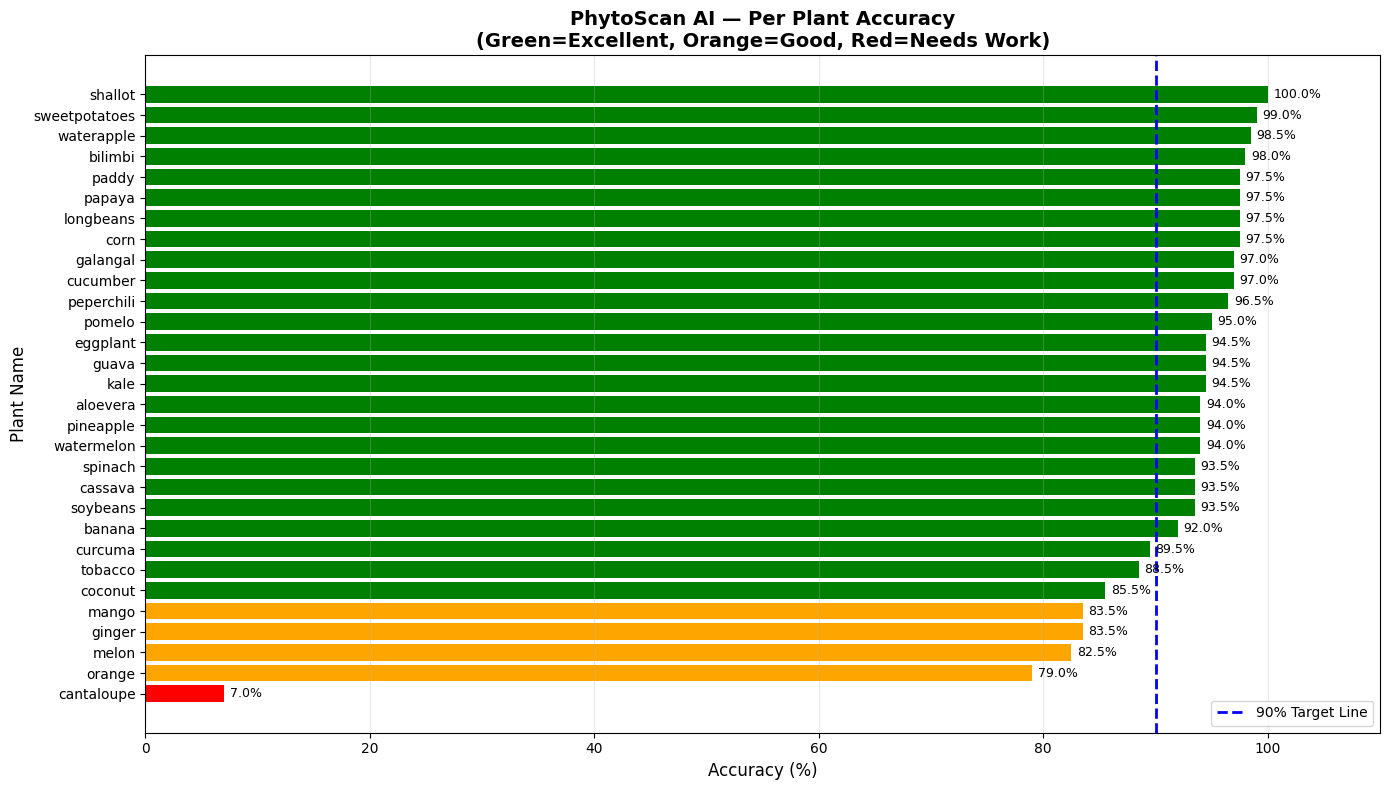

Per plant accuracy chart saved!

Bottom 3 plants needing improvement:
  cantaloupe: 7.0%
  orange: 79.0%
  melon: 82.5%

Top 3 best recognized plants:
  shallot: 100.0%
  sweetpotatoes: 99.0%
  waterapple: 98.5%


In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix

# Calculate per-class accuracy
cm = confusion_matrix(true_classes, predicted_classes)
per_class_acc = cm.diagonal() / cm.sum(axis=1) * 100

# Sort by accuracy
sorted_idx = np.argsort(per_class_acc)
sorted_plants = [class_labels[i] for i in sorted_idx]
sorted_acc = per_class_acc[sorted_idx]

# Color bars
colors = ['red' if a < 70 else 'orange' if a < 85 else 'green'
          for a in sorted_acc]

# Plot
plt.figure(figsize=(14, 8))
bars = plt.barh(sorted_plants, sorted_acc, color=colors)

# Add value labels
for bar, acc in zip(bars, sorted_acc):
    plt.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
             f'{acc:.1f}%', va='center', fontsize=9)

plt.axvline(x=90, color='blue', linestyle='--',
            linewidth=2, label='90% Target Line')
plt.title('PhytoScan AI — Per Plant Accuracy\n(Green=Excellent, Orange=Good, Red=Needs Work)',
          fontsize=14, fontweight='bold')
plt.xlabel('Accuracy (%)', fontsize=12)
plt.ylabel('Plant Name', fontsize=12)
plt.xlim([0, 110])
plt.legend()
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()

plt.savefig('/content/drive/MyDrive/PhytoScan/per_plant_accuracy.png',
            dpi=150, bbox_inches='tight')
plt.show()

print("Per plant accuracy chart saved!")
print("\nBottom 3 plants needing improvement:")
for i in range(3):
    print(f"  {sorted_plants[i]}: {sorted_acc[i]:.1f}%")

print("\nTop 3 best recognized plants:")
for i in range(-1, -4, -1):
    print(f"  {sorted_plants[i]}: {sorted_acc[i]:.1f}%")

   PHYTOSCAN AI — FINAL STATISTICS REPORT

Overall Accuracy:      90.27%
Mean Class Accuracy:   90.27%
Median Accuracy:       94.25%
Std Deviation:         16.36%
Best Plant Accuracy:   100.00%
Worst Plant Accuracy:  7.00%
Total Plants:          30
Total Test Images:     6000
Correctly Identified:  5416
Wrongly Identified:    584


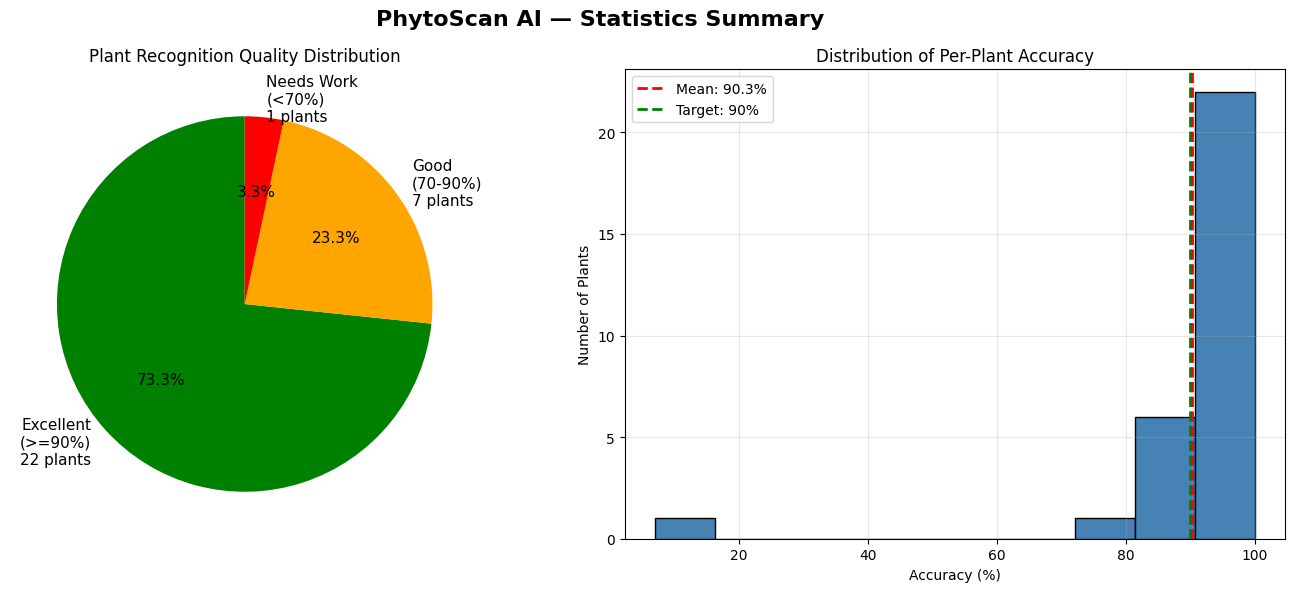


All statistics saved to Google Drive!


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import (confusion_matrix,
                             classification_report,
                             accuracy_score)

# Overall statistics
overall_acc = accuracy_score(true_classes, predicted_classes)

# Per class accuracy
cm = confusion_matrix(true_classes, predicted_classes)
per_class_acc = cm.diagonal() / cm.sum(axis=1) * 100

# Statistics
mean_acc    = np.mean(per_class_acc)
median_acc  = np.median(per_class_acc)
std_acc     = np.std(per_class_acc)
min_acc     = np.min(per_class_acc)
max_acc     = np.max(per_class_acc)

print("="*50)
print("   PHYTOSCAN AI — FINAL STATISTICS REPORT")
print("="*50)
print(f"\nOverall Accuracy:      {overall_acc*100:.2f}%")
print(f"Mean Class Accuracy:   {mean_acc:.2f}%")
print(f"Median Accuracy:       {median_acc:.2f}%")
print(f"Std Deviation:         {std_acc:.2f}%")
print(f"Best Plant Accuracy:   {max_acc:.2f}%")
print(f"Worst Plant Accuracy:  {min_acc:.2f}%")
print(f"Total Plants:          {len(class_labels)}")
print(f"Total Test Images:     {len(true_classes)}")
print(f"Correctly Identified:  {int(overall_acc*len(true_classes))}")
print(f"Wrongly Identified:    {len(true_classes)-int(overall_acc*len(true_classes))}")
print("="*50)

# Distribution pie chart
excellent = sum(1 for a in per_class_acc if a >= 90)
good      = sum(1 for a in per_class_acc if 70 <= a < 90)
poor      = sum(1 for a in per_class_acc if a < 70)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('PhytoScan AI — Statistics Summary',
             fontsize=16, fontweight='bold')

# Pie chart
axes[0].pie(
    [excellent, good, poor],
    labels=[f'Excellent\n(>=90%)\n{excellent} plants',
            f'Good\n(70-90%)\n{good} plants',
            f'Needs Work\n(<70%)\n{poor} plants'],
    colors=['green', 'orange', 'red'],
    autopct='%1.1f%%',
    startangle=90,
    textprops={'fontsize': 11}
)
axes[0].set_title('Plant Recognition Quality Distribution')

# Histogram
axes[1].hist(per_class_acc, bins=10,
             color='steelblue', edgecolor='black')
axes[1].axvline(x=mean_acc, color='red',
                linestyle='--', linewidth=2,
                label=f'Mean: {mean_acc:.1f}%')
axes[1].axvline(x=90, color='green',
                linestyle='--', linewidth=2,
                label='Target: 90%')
axes[1].set_title('Distribution of Per-Plant Accuracy')
axes[1].set_xlabel('Accuracy (%)')
axes[1].set_ylabel('Number of Plants')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/PhytoScan/statistics_summary.png',
            dpi=150, bbox_inches='tight')
plt.show()

# Save stats
with open('/content/drive/MyDrive/PhytoScan/statistics_report.txt', 'w') as f:
    f.write("PHYTOSCAN AI - FINAL STATISTICS REPORT\n")
    f.write("="*50 + "\n")
    f.write(f"Overall Accuracy:      {overall_acc*100:.2f}%\n")
    f.write(f"Mean Class Accuracy:   {mean_acc:.2f}%\n")
    f.write(f"Median Accuracy:       {median_acc:.2f}%\n")
    f.write(f"Std Deviation:         {std_acc:.2f}%\n")
    f.write(f"Best Plant Accuracy:   {max_acc:.2f}%\n")
    f.write(f"Worst Plant Accuracy:  {min_acc:.2f}%\n")
    f.write(f"Total Plants:          {len(class_labels)}\n")
    f.write(f"Total Test Images:     {len(true_classes)}\n")

print("\nAll statistics saved to Google Drive!")

In [ ]:
import json

knowledge_base = {
    "aloevera": {
        "common_name": "Aloe Vera",
        "scientific_name": "Aloe barbadensis miller",
        "origin": "Arabian Peninsula, North Africa",
        "family": "Asphodelaceae",
        "chemical_compounds": [
            "Aloin", "Aloe-emodin", "Acemannan",
            "Anthraquinones", "Vitamins C and E"
        ],
        "medical_uses": [
            "Burns and wound healing",
            "Skin inflammation and eczema",
            "Digestive health and constipation",
            "Immune system support",
            "Anti-inflammatory treatment"
        ],
        "toxicity": "Safe",
        "toxicity_level": 0,
        "dosage": {
            "gel_topical": "Apply directly to skin 2-3 times daily",
            "juice_oral": "1-2 tablespoons (30ml) per day",
            "capsule": "100-200mg per day"
        },
        "preparation": "Cut leaf, extract clear gel, apply directly or blend for juice",
        "contraindications": [
            "Avoid oral use during pregnancy",
            "Do not use on deep wounds",
            "May interact with diabetes medications"
        ],
        "combinations": {
            "ginger": {"effect": "Synergistic",
                      "result": "Enhanced anti-inflammatory effect"},
            "turmeric": {"effect": "Synergistic",
                        "result": "Powerful skin healing combination"},
            "tobacco": {"effect": "Dangerous",
                       "result": "Never combine — toxic interaction"}
        }
    },
    "ginger": {
        "common_name": "Ginger",
        "scientific_name": "Zingiber officinale",
        "origin": "Southeast Asia, India",
        "family": "Zingiberaceae",
        "chemical_compounds": [
            "Gingerol", "Shogaol", "Zingerone",
            "Paradol", "Volatile oils"
        ],
        "medical_uses": [
            "Nausea and vomiting relief",
            "Anti-inflammatory treatment",
            "Digestive aid",
            "Pain relief",
            "Common cold treatment"
        ],
        "toxicity": "Safe",
        "toxicity_level": 0,
        "dosage": {
            "fresh_root": "2-4 grams per day",
            "tea": "1-2 cups daily",
            "powder": "0.5-1 gram per day"
        },
        "preparation": "Slice fresh root for tea, or dry and grind into powder",
        "contraindications": [
            "High doses may cause heartburn",
            "Caution with blood thinning medications",
            "Consult doctor if pregnant"
        ],
        "combinations": {
            "aloevera": {"effect": "Synergistic",
                        "result": "Enhanced anti-inflammatory effect"},
            "curcuma": {"effect": "Synergistic",
                       "result": "Powerful digestive and anti-inflammatory combination"},
            "tobacco": {"effect": "Dangerous",
                       "result": "Never combine — reduces therapeutic benefits"}
        }
    },
    "curcuma": {
        "common_name": "Turmeric",
        "scientific_name": "Curcuma longa",
        "origin": "South Asia, India",
        "family": "Zingiberaceae",
        "chemical_compounds": [
            "Curcumin", "Bisdemethoxycurcumin",
            "Demethoxycurcumin", "Volatile oils", "Turmerone"
        ],
        "medical_uses": [
            "Powerful anti-inflammatory",
            "Antioxidant protection",
            "Joint pain and arthritis",
            "Liver protection",
            "Cancer prevention research"
        ],
        "toxicity": "Safe",
        "toxicity_level": 0,
        "dosage": {
            "powder": "1-3 grams per day",
            "tea": "1 cup daily with black pepper",
            "capsule": "500mg twice daily"
        },
        "preparation": "Mix powder in warm milk or tea. Always add black pepper to increase absorption by 2000%",
        "contraindications": [
            "Avoid high doses during pregnancy",
            "May slow blood clotting",
            "Caution with gallbladder disease"
        ],
        "combinations": {
            "ginger": {"effect": "Synergistic",
                      "result": "Powerful anti-inflammatory and digestive aid"},
            "aloevera": {"effect": "Synergistic",
                        "result": "Enhanced skin healing"},
            "tobacco": {"effect": "Dangerous",
                       "result": "Never combine — toxic to liver"}
        }
    },
    "banana": {
        "common_name": "Banana",
        "scientific_name": "Musa paradisiaca",
        "origin": "Southeast Asia, Papua New Guinea",
        "family": "Musaceae",
        "chemical_compounds": [
            "Potassium", "Vitamin B6", "Dopamine",
            "Catechins", "Pectin"
        ],
        "medical_uses": [
            "Heart health and blood pressure",
            "Digestive health",
            "Energy boost",
            "Mood improvement",
            "Kidney health"
        ],
        "toxicity": "Safe",
        "toxicity_level": 0,
        "dosage": {
            "fresh_fruit": "1-2 bananas per day",
            "leaf_tea": "1 cup daily",
            "flower": "50-100g cooked daily"
        },
        "preparation": "Eat fresh, or boil leaves for tea",
        "contraindications": [
            "Diabetics should limit intake",
            "High potassium — caution with kidney disease"
        ],
        "combinations": {
            "ginger": {"effect": "Synergistic",
                      "result": "Enhanced digestive health"},
            "spinach": {"effect": "Additive",
                       "result": "Good nutritional combination"}
        }
    },
    "guava": {
        "common_name": "Guava",
        "scientific_name": "Psidium guajava",
        "origin": "Central America, Mexico",
        "family": "Myrtaceae",
        "chemical_compounds": [
            "Vitamin C", "Lycopene", "Quercetin",
            "Potassium", "Tannins"
        ],
        "medical_uses": [
            "Immune system boost",
            "Diarrhea treatment",
            "Blood sugar control",
            "Heart health",
            "Anti-cancer properties"
        ],
        "toxicity": "Safe",
        "toxicity_level": 0,
        "dosage": {
            "fresh_fruit": "1-2 fruits daily",
            "leaf_tea": "2-3 cups daily",
            "powder": "3-5 grams daily"
        },
        "preparation": "Boil 5-6 leaves in water for 10 minutes for medicinal tea",
        "contraindications": [
            "May lower blood sugar — caution for diabetics on medication",
            "Avoid excess during pregnancy"
        ],
        "combinations": {
            "aloevera": {"effect": "Synergistic",
                        "result": "Enhanced immune support"},
            "ginger": {"effect": "Additive",
                      "result": "Good digestive combination"}
        }
    },
    "papaya": {
        "common_name": "Papaya",
        "scientific_name": "Carica papaya",
        "origin": "Central America, Mexico",
        "family": "Caricaceae",
        "chemical_compounds": [
            "Papain", "Chymopapain", "Vitamin C",
            "Beta-carotene", "Carpaine"
        ],
        "medical_uses": [
            "Digestive enzyme support",
            "Dengue fever treatment",
            "Wound healing",
            "Anti-parasitic",
            "Skin health"
        ],
        "toxicity": "Mild Caution",
        "toxicity_level": 1,
        "dosage": {
            "fresh_fruit": "1 cup daily",
            "leaf_juice": "30ml twice daily for dengue",
            "seeds": "1 teaspoon daily maximum"
        },
        "preparation": "Eat fresh fruit or juice leaves for medicinal use",
        "contraindications": [
            "Avoid during pregnancy — can cause contractions",
            "Seeds are mildly toxic in large amounts",
            "Caution with blood thinners"
        ],
        "combinations": {
            "ginger": {"effect": "Synergistic",
                      "result": "Enhanced digestive support"},
            "aloevera": {"effect": "Additive",
                        "result": "Good skin healing combination"}
        }
    },
    "tobacco": {
        "common_name": "Tobacco",
        "scientific_name": "Nicotiana tabacum",
        "origin": "Americas",
        "family": "Solanaceae",
        "chemical_compounds": [
            "Nicotine", "Nornicotine", "Anabasine",
            "Cotinine", "Alkaloids"
        ],
        "medical_uses": [
            "Historical use as pain reliever",
            "Traditional wound dressing",
            "Insecticide (nicotine based)",
            "Research use only"
        ],
        "toxicity": "Highly Toxic",
        "toxicity_level": 3,
        "dosage": {
            "warning": "NO safe medicinal dose for internal use",
            "external": "Never apply to broken skin"
        },
        "preparation": "NOT recommended for any home preparation",
        "contraindications": [
            "Highly addictive",
            "Causes cancer",
            "Never consume internally",
            "Keep away from children",
            "Dangerous with ALL other herbs"
        ],
        "combinations": {
            "aloevera": {"effect": "Dangerous",
                        "result": "Toxic interaction"},
            "ginger": {"effect": "Dangerous",
                      "result": "Toxic interaction"},
            "curcuma": {"effect": "Dangerous",
                       "result": "Never combine with any medicinal herb"}
        }
    },
    "spinach": {
        "common_name": "Spinach",
        "scientific_name": "Spinacia oleracea",
        "origin": "Central and Western Asia",
        "family": "Amaranthaceae",
        "chemical_compounds": [
            "Iron", "Vitamin K", "Lutein",
            "Zeaxanthin", "Folate"
        ],
        "medical_uses": [
            "Anemia treatment",
            "Bone health",
            "Eye health",
            "Blood pressure control",
            "Pregnancy nutrition"
        ],
        "toxicity": "Safe",
        "toxicity_level": 0,
        "dosage": {
            "fresh": "1-2 cups daily",
            "cooked": "0.5-1 cup daily",
            "juice": "100-200ml daily"
        },
        "preparation": "Eat fresh in salad or lightly cooked",
        "contraindications": [
            "High oxalates — caution with kidney stones",
            "May interact with blood thinners (Vitamin K)"
        ],
        "combinations": {
            "banana": {"effect": "Additive",
                      "result": "Excellent nutritional combination"},
            "ginger": {"effect": "Synergistic",
                      "result": "Enhanced iron absorption"}
        }
    },
    "mango": {
        "common_name": "Mango",
        "scientific_name": "Mangifera indica",
        "origin": "South Asia, India",
        "family": "Anacardiaceae",
        "chemical_compounds": [
            "Mangiferin", "Vitamin C", "Beta-carotene",
            "Quercetin", "Gallic acid"
        ],
        "medical_uses": [
            "Immune system support",
            "Digestive health",
            "Eye health",
            "Anti-inflammatory",
            "Blood sugar regulation"
        ],
        "toxicity": "Safe",
        "toxicity_level": 0,
        "dosage": {
            "fresh_fruit": "1 cup daily",
            "leaf_tea": "2 cups daily",
            "bark_extract": "Consult herbalist"
        },
        "preparation": "Eat fresh or boil young leaves for tea",
        "contraindications": [
            "High sugar — limit for diabetics",
            "Mango skin may cause allergic reaction"
        ],
        "combinations": {
            "ginger": {"effect": "Synergistic",
                      "result": "Enhanced digestive health"},
            "curcuma": {"effect": "Additive",
                       "result": "Good anti-inflammatory combination"}
        }
    },
    "coconut": {
        "common_name": "Coconut",
        "scientific_name": "Cocos nucifera",
        "origin": "Indo-Pacific region",
        "family": "Arecaceae",
        "chemical_compounds": [
            "Lauric acid", "Medium chain triglycerides",
            "Vitamin E", "Caprylic acid", "Electrolytes"
        ],
        "medical_uses": [
            "Antimicrobial properties",
            "Heart health",
            "Skin and hair care",
            "Hydration and electrolytes",
            "Thyroid support"
        ],
        "toxicity": "Safe",
        "toxicity_level": 0,
        "dosage": {
            "coconut_water": "1-2 cups daily",
            "coconut_oil": "1-2 tablespoons daily",
            "fresh_meat": "30-50g daily"
        },
        "preparation": "Use fresh coconut water or cold pressed coconut oil",
        "contraindications": [
            "High in saturated fat — limit with heart disease",
            "High calorie — limit for weight loss"
        ],
        "combinations": {
            "aloevera": {"effect": "Synergistic",
                        "result": "Excellent skin moisturizing combination"},
            "ginger": {"effect": "Additive",
                      "result": "Good digestive combination"}
        }
    }
}

# Save knowledge base
with open('/content/drive/MyDrive/PhytoScan/knowledge_base.json', 'w') as f:
    json.dump(knowledge_base, f, indent=2)

print("Knowledge Base Created!")
print(f"Total plants with full info: {len(knowledge_base)}")
print("\nPlants covered:")
for plant in knowledge_base:
    toxicity = knowledge_base[plant]['toxicity']
    print(f"  - {plant:15} | {toxicity}")

Knowledge Base Created!
Total plants with full info: 10

Plants covered:
  - aloevera        | Safe
  - ginger          | Safe
  - curcuma         | Safe
  - banana          | Safe
  - guava           | Safe
  - papaya          | Mild Caution
  - tobacco         | Highly Toxic
  - spinach         | Safe
  - mango           | Safe
  - coconut         | Safe


In [ ]:
remaining_plants = {
    "bilimbi": {
        "common_name": "Bilimbi",
        "scientific_name": "Averrhoa bilimbi",
        "origin": "Southeast Asia, Indonesia",
        "family": "Oxalidaceae",
        "chemical_compounds": [
            "Oxalic acid", "Vitamin C", "Tannins",
            "Saponins", "Flavonoids"
        ],
        "medical_uses": [
            "Fever reduction",
            "Skin disease treatment",
            "High blood pressure",
            "Diabetes management",
            "Anti-inflammatory"
        ],
        "toxicity": "Mild Caution",
        "toxicity_level": 1,
        "dosage": {
            "fruit_juice": "30ml twice daily",
            "leaf_tea": "1 cup daily",
            "fresh_fruit": "2-3 fruits daily maximum"
        },
        "preparation": "Boil leaves for tea or juice fresh fruit",
        "contraindications": [
            "High oxalic acid — avoid with kidney disease",
            "Do not consume in large amounts",
            "Caution for kidney stone patients"
        ],
        "combinations": {
            "ginger": {"effect": "Synergistic",
                      "result": "Enhanced fever reduction"},
            "guava": {"effect": "Additive",
                     "result": "Good blood sugar control combination"}
        }
    },
    "cantaloupe": {
        "common_name": "Cantaloupe",
        "scientific_name": "Cucumis melo",
        "origin": "South Asia, Africa",
        "family": "Cucurbitaceae",
        "chemical_compounds": [
            "Beta-carotene", "Vitamin C", "Potassium",
            "Folate", "Adenosine"
        ],
        "medical_uses": [
            "Eye health improvement",
            "Immune system support",
            "Heart health",
            "Hydration",
            "Anti-cancer properties"
        ],
        "toxicity": "Safe",
        "toxicity_level": 0,
        "dosage": {
            "fresh_fruit": "1-2 cups daily",
            "juice": "200ml daily"
        },
        "preparation": "Eat fresh or juice",
        "contraindications": [
            "High sugar content — limit for diabetics",
            "Wash thoroughly before eating"
        ],
        "combinations": {
            "spinach": {"effect": "Additive",
                       "result": "Excellent vitamin combination"},
            "ginger": {"effect": "Additive",
                      "result": "Good digestive health"}
        }
    },
    "cassava": {
        "common_name": "Cassava",
        "scientific_name": "Manihot esculenta",
        "origin": "South America, Brazil",
        "family": "Euphorbiaceae",
        "chemical_compounds": [
            "Starch", "Linamarin", "Vitamin C",
            "Calcium", "Phosphorus"
        ],
        "medical_uses": [
            "Energy source",
            "Digestive health",
            "Wound healing (leaf poultice)",
            "Headache relief",
            "Fever reduction"
        ],
        "toxicity": "Moderate Toxic",
        "toxicity_level": 2,
        "dosage": {
            "cooked_root": "100-200g daily when fully cooked",
            "leaf": "Only eat well cooked leaves"
        },
        "preparation": "MUST be cooked thoroughly — raw cassava contains cyanide compounds",
        "contraindications": [
            "NEVER eat raw — contains cyanogenic glycosides",
            "Must be soaked and cooked properly",
            "Not for people with iodine deficiency"
        ],
        "combinations": {
            "spinach": {"effect": "Additive",
                       "result": "Good nutritional balance"},
            "ginger": {"effect": "Neutral",
                      "result": "No significant interaction"}
        }
    },
    "corn": {
        "common_name": "Corn / Maize",
        "scientific_name": "Zea mays",
        "origin": "Mexico, Central America",
        "family": "Poaceae",
        "chemical_compounds": [
            "Zeaxanthin", "Lutein", "Vitamin B",
            "Ferulic acid", "Phytic acid"
        ],
        "medical_uses": [
            "Eye health",
            "Digestive health",
            "Energy source",
            "Corn silk for kidney health",
            "Urinary tract infections"
        ],
        "toxicity": "Safe",
        "toxicity_level": 0,
        "dosage": {
            "corn_silk_tea": "2-3 cups daily",
            "fresh_corn": "1-2 ears daily",
            "cornmeal": "As needed"
        },
        "preparation": "Boil corn silk for medicinal tea",
        "contraindications": [
            "High carbohydrate — limit for diabetics",
            "Corn silk may interact with diuretics"
        ],
        "combinations": {
            "spinach": {"effect": "Additive",
                       "result": "Good nutritional combination"},
            "ginger": {"effect": "Neutral",
                      "result": "No significant interaction"}
        }
    },
    "cucumber": {
        "common_name": "Cucumber",
        "scientific_name": "Cucumis sativus",
        "origin": "South Asia, India",
        "family": "Cucurbitaceae",
        "chemical_compounds": [
            "Cucurbitacins", "Vitamin K", "Silica",
            "Fisetin", "Caffeic acid"
        ],
        "medical_uses": [
            "Hydration and cooling",
            "Skin care and sunburn",
            "Blood pressure reduction",
            "Anti-inflammatory",
            "Kidney health"
        ],
        "toxicity": "Safe",
        "toxicity_level": 0,
        "dosage": {
            "fresh": "1-2 cucumbers daily",
            "juice": "100-200ml daily",
            "topical": "Apply slices directly to skin"
        },
        "preparation": "Eat fresh or apply slices to skin",
        "contraindications": [
            "Wash thoroughly before eating",
            "May cause bloating in some people"
        ],
        "combinations": {
            "aloevera": {"effect": "Synergistic",
                        "result": "Excellent skin cooling combination"},
            "spinach": {"effect": "Additive",
                       "result": "Good hydration and nutrition"}
        }
    },
    "eggplant": {
        "common_name": "Eggplant / Brinjal",
        "scientific_name": "Solanum melongena",
        "origin": "South Asia, India",
        "family": "Solanaceae",
        "chemical_compounds": [
            "Nasunin", "Chlorogenic acid", "Vitamin B6",
            "Solanine", "Fiber"
        ],
        "medical_uses": [
            "Heart health",
            "Blood sugar control",
            "Weight management",
            "Brain health",
            "Anti-cancer properties"
        ],
        "toxicity": "Mild Caution",
        "toxicity_level": 1,
        "dosage": {
            "cooked": "100-150g daily",
            "juice": "50ml daily maximum"
        },
        "preparation": "Always cook thoroughly before eating",
        "contraindications": [
            "Raw eggplant contains solanine — mildly toxic",
            "Avoid if allergic to nightshade plants",
            "Caution with iron absorption medications"
        ],
        "combinations": {
            "ginger": {"effect": "Synergistic",
                      "result": "Enhanced digestive health"},
            "curcuma": {"effect": "Additive",
                       "result": "Good anti-inflammatory combination"}
        }
    },
    "galangal": {
        "common_name": "Galangal",
        "scientific_name": "Alpinia galanga",
        "origin": "Southeast Asia, Indonesia",
        "family": "Zingiberaceae",
        "chemical_compounds": [
            "Galangin", "Alpinen", "Kaempferide",
            "Essential oils", "Terpenes"
        ],
        "medical_uses": [
            "Digestive aid",
            "Anti-nausea",
            "Anti-fungal treatment",
            "Pain relief",
            "Respiratory health"
        ],
        "toxicity": "Safe",
        "toxicity_level": 0,
        "dosage": {
            "fresh_root": "2-4 grams daily",
            "tea": "1-2 cups daily",
            "powder": "1 gram daily"
        },
        "preparation": "Slice fresh root and boil for tea",
        "contraindications": [
            "Avoid high doses during pregnancy",
            "May interact with blood thinners"
        ],
        "combinations": {
            "ginger": {"effect": "Synergistic",
                      "result": "Very powerful digestive combination"},
            "curcuma": {"effect": "Synergistic",
                       "result": "Excellent anti-inflammatory trio"}
        }
    },
    "kale": {
        "common_name": "Kale",
        "scientific_name": "Brassica oleracea",
        "origin": "Eastern Mediterranean, Asia Minor",
        "family": "Brassicaceae",
        "chemical_compounds": [
            "Vitamin K", "Vitamin C", "Sulforaphane",
            "Lutein", "Indole-3-carbinol"
        ],
        "medical_uses": [
            "Bone health",
            "Cancer prevention",
            "Heart health",
            "Eye health",
            "Detoxification"
        ],
        "toxicity": "Safe",
        "toxicity_level": 0,
        "dosage": {
            "fresh": "1-2 cups daily",
            "juice": "100ml daily",
            "cooked": "0.5-1 cup daily"
        },
        "preparation": "Eat fresh in salad or lightly steam",
        "contraindications": [
            "High Vitamin K — caution with blood thinners",
            "May affect thyroid if eaten raw in large amounts"
        ],
        "combinations": {
            "spinach": {"effect": "Additive",
                       "result": "Excellent green nutrition combination"},
            "ginger": {"effect": "Synergistic",
                      "result": "Enhanced detoxification"}
        }
    },
    "longbeans": {
        "common_name": "Long Beans",
        "scientific_name": "Vigna unguiculata",
        "origin": "West Africa, Asia",
        "family": "Fabaceae",
        "chemical_compounds": [
            "Protein", "Folate", "Iron",
            "Magnesium", "Vitamin B"
        ],
        "medical_uses": [
            "Blood sugar control",
            "Heart health",
            "Digestive health",
            "Pregnancy nutrition",
            "Energy boost"
        ],
        "toxicity": "Safe",
        "toxicity_level": 0,
        "dosage": {
            "cooked": "100-150g daily",
            "fresh": "As part of balanced diet"
        },
        "preparation": "Cook thoroughly before eating",
        "contraindications": [
            "May cause gas in some people",
            "Moderation advised for kidney patients"
        ],
        "combinations": {
            "spinach": {"effect": "Additive",
                       "result": "Excellent iron and protein combination"},
            "ginger": {"effect": "Neutral",
                      "result": "No significant interaction"}
        }
    },
    "melon": {
        "common_name": "Melon",
        "scientific_name": "Cucumis melo",
        "origin": "Africa, South Asia",
        "family": "Cucurbitaceae",
        "chemical_compounds": [
            "Vitamin C", "Beta-carotene", "Potassium",
            "Cucurbitacin", "Water content 90%"
        ],
        "medical_uses": [
            "Hydration",
            "Kidney health",
            "Blood pressure control",
            "Immune support",
            "Skin health"
        ],
        "toxicity": "Safe",
        "toxicity_level": 0,
        "dosage": {
            "fresh_fruit": "1-2 cups daily",
            "juice": "200ml daily"
        },
        "preparation": "Eat fresh or juice",
        "contraindications": [
            "High sugar — limit for diabetics",
            "Do not eat with other fruits for best digestion"
        ],
        "combinations": {
            "ginger": {"effect": "Additive",
                      "result": "Good digestive combination"},
            "cucumber": {"effect": "Synergistic",
                        "result": "Excellent hydration combination"}
        }
    },
    "orange": {
        "common_name": "Orange",
        "scientific_name": "Citrus sinensis",
        "origin": "Southeast Asia, China",
        "family": "Rutaceae",
        "chemical_compounds": [
            "Vitamin C", "Flavonoids", "Hesperidin",
            "Limonene", "Pectin"
        ],
        "medical_uses": [
            "Immune system boost",
            "Heart health",
            "Kidney stone prevention",
            "Anti-inflammatory",
            "Skin health"
        ],
        "toxicity": "Safe",
        "toxicity_level": 0,
        "dosage": {
            "fresh_fruit": "1-2 oranges daily",
            "juice": "200ml daily",
            "peel_tea": "1 cup daily"
        },
        "preparation": "Eat fresh or juice. Boil peel for medicinal tea",
        "contraindications": [
            "Acidic — avoid with acid reflux",
            "May interact with certain medications"
        ],
        "combinations": {
            "ginger": {"effect": "Synergistic",
                      "result": "Excellent immune boosting combination"},
            "guava": {"effect": "Synergistic",
                     "result": "Powerful Vitamin C combination"}
        }
    },
    "paddy": {
        "common_name": "Rice / Paddy",
        "scientific_name": "Oryza sativa",
        "origin": "China, Southeast Asia",
        "family": "Poaceae",
        "chemical_compounds": [
            "Starch", "Vitamin B1", "Gamma oryzanol",
            "Ferulic acid", "Phytic acid"
        ],
        "medical_uses": [
            "Digestive health",
            "Energy source",
            "Diarrhea treatment",
            "Rice water for skin care",
            "Blood pressure support"
        ],
        "toxicity": "Safe",
        "toxicity_level": 0,
        "dosage": {
            "cooked_rice": "1-2 cups daily",
            "rice_water": "1-2 cups daily"
        },
        "preparation": "Cook rice water by boiling rice in extra water",
        "contraindications": [
            "High glycemic — limit for diabetics",
            "Brown rice preferred for full nutrition"
        ],
        "combinations": {
            "ginger": {"effect": "Additive",
                      "result": "Good digestive combination"},
            "spinach": {"effect": "Additive",
                       "result": "Good nutritional balance"}
        }
    },
    "peperchili": {
        "common_name": "Chili Pepper",
        "scientific_name": "Capsicum annuum",
        "origin": "Mexico, Central America",
        "family": "Solanaceae",
        "chemical_compounds": [
            "Capsaicin", "Vitamin C", "Beta-carotene",
            "Quercetin", "Lutein"
        ],
        "medical_uses": [
            "Pain relief (topical capsaicin)",
            "Metabolism boost",
            "Heart health",
            "Anti-inflammatory",
            "Nasal congestion relief"
        ],
        "toxicity": "Mild Caution",
        "toxicity_level": 1,
        "dosage": {
            "fresh": "1-2 chilies daily maximum",
            "powder": "0.5-1 gram daily",
            "topical_cream": "Apply 3-4 times daily"
        },
        "preparation": "Use fresh in food or dry and grind for powder",
        "contraindications": [
            "Avoid with acid reflux or ulcers",
            "Can irritate skin — wash hands after handling",
            "Avoid eyes contact"
        ],
        "combinations": {
            "ginger": {"effect": "Synergistic",
                      "result": "Powerful metabolism boost combination"},
            "curcuma": {"effect": "Synergistic",
                       "result": "Enhanced anti-inflammatory effect"}
        }
    },
    "pineapple": {
        "common_name": "Pineapple",
        "scientific_name": "Ananas comosus",
        "origin": "South America, Brazil",
        "family": "Bromeliaceae",
        "chemical_compounds": [
            "Bromelain", "Vitamin C", "Manganese",
            "Thiamine", "Antioxidants"
        ],
        "medical_uses": [
            "Digestive enzyme support",
            "Anti-inflammatory",
            "Immune system boost",
            "Bone health",
            "Wound healing"
        ],
        "toxicity": "Safe",
        "toxicity_level": 0,
        "dosage": {
            "fresh_fruit": "1 cup daily",
            "juice": "150ml daily",
            "bromelain_supplement": "200-400mg daily"
        },
        "preparation": "Eat fresh or juice. Core contains most bromelain",
        "contraindications": [
            "Avoid during pregnancy in large amounts",
            "May interact with blood thinners",
            "Acidic — avoid with acid reflux"
        ],
        "combinations": {
            "ginger": {"effect": "Synergistic",
                      "result": "Excellent digestive and anti-inflammatory combination"},
            "curcuma": {"effect": "Synergistic",
                       "result": "Powerful anti-inflammatory combination"}
        }
    },
    "pomelo": {
        "common_name": "Pomelo",
        "scientific_name": "Citrus maxima",
        "origin": "Southeast Asia, Malaysia",
        "family": "Rutaceae",
        "chemical_compounds": [
            "Vitamin C", "Naringenin", "Lycopene",
            "Potassium", "Bioflavonoids"
        ],
        "medical_uses": [
            "Immune system support",
            "Heart health",
            "Weight management",
            "Anti-aging",
            "Blood pressure control"
        ],
        "toxicity": "Safe",
        "toxicity_level": 0,
        "dosage": {
            "fresh_fruit": "1-2 segments daily",
            "juice": "150ml daily"
        },
        "preparation": "Eat fresh segments or juice",
        "contraindications": [
            "Interacts with many medications like grapefruit",
            "Consult doctor if on any medication"
        ],
        "combinations": {
            "ginger": {"effect": "Additive",
                      "result": "Good immune support combination"},
            "orange": {"effect": "Synergistic",
                      "result": "Powerful Vitamin C boost"}
        }
    },
    "shallot": {
        "common_name": "Shallot",
        "scientific_name": "Allium ascalonicum",
        "origin": "Central Asia, Middle East",
        "family": "Amaryllidaceae",
        "chemical_compounds": [
            "Allicin", "Quercetin", "Kaempferol",
            "Sulfur compounds", "Vitamin B6"
        ],
        "medical_uses": [
            "Antimicrobial properties",
            "Heart health",
            "Blood sugar control",
            "Anti-inflammatory",
            "Immune system support"
        ],
        "toxicity": "Safe",
        "toxicity_level": 0,
        "dosage": {
            "fresh": "2-3 shallots daily",
            "cooked": "As needed in food",
            "extract": "300-500mg daily"
        },
        "preparation": "Eat raw for maximum benefit or lightly cook",
        "contraindications": [
            "May cause heartburn in some people",
            "Caution with blood thinning medications"
        ],
        "combinations": {
            "ginger": {"effect": "Synergistic",
                      "result": "Powerful antimicrobial combination"},
            "curcuma": {"effect": "Synergistic",
                       "result": "Excellent immune boosting combination"}
        }
    },
    "soybeans": {
        "common_name": "Soybeans",
        "scientific_name": "Glycine max",
        "origin": "East Asia, China",
        "family": "Fabaceae",
        "chemical_compounds": [
            "Isoflavones", "Protein", "Omega-3",
            "Phytoestrogens", "Saponins"
        ],
        "medical_uses": [
            "Heart health",
            "Menopause symptom relief",
            "Bone health",
            "Blood sugar control",
            "Cancer prevention research"
        ],
        "toxicity": "Safe",
        "toxicity_level": 0,
        "dosage": {
            "cooked_beans": "100g daily",
            "soy_milk": "200ml daily",
            "tofu": "100-150g daily"
        },
        "preparation": "Cook thoroughly before eating",
        "contraindications": [
            "Avoid with thyroid conditions",
            "Phytoestrogens may affect hormone-sensitive conditions",
            "Soy allergy is common"
        ],
        "combinations": {
            "spinach": {"effect": "Additive",
                       "result": "Excellent protein and iron combination"},
            "ginger": {"effect": "Neutral",
                      "result": "No significant interaction"}
        }
    },
    "sweetpotatoes": {
        "common_name": "Sweet Potato",
        "scientific_name": "Ipomoea batatas",
        "origin": "Central and South America",
        "family": "Convolvulaceae",
        "chemical_compounds": [
            "Beta-carotene", "Vitamin C", "Potassium",
            "Anthocyanins", "Chlorogenic acid"
        ],
        "medical_uses": [
            "Blood sugar regulation",
            "Eye health",
            "Immune support",
            "Heart health",
            "Anti-inflammatory"
        ],
        "toxicity": "Safe",
        "toxicity_level": 0,
        "dosage": {
            "cooked": "100-150g daily",
            "baked": "1 medium potato daily",
            "leaf_tea": "1-2 cups daily"
        },
        "preparation": "Bake, steam or boil. Leaves also edible and medicinal",
        "contraindications": [
            "High potassium — caution with kidney disease",
            "Moderate glycemic — watch portions for diabetics"
        ],
        "combinations": {
            "spinach": {"effect": "Additive",
                       "result": "Excellent nutritional combination"},
            "ginger": {"effect": "Synergistic",
                      "result": "Enhanced blood sugar control"}
        }
    },
    "waterapple": {
        "common_name": "Water Apple / Rose Apple",
        "scientific_name": "Syzygium aqueum",
        "origin": "Southeast Asia, Malaysia",
        "family": "Myrtaceae",
        "chemical_compounds": [
            "Vitamin C", "Tannins", "Saponins",
            "Flavonoids", "Fiber"
        ],
        "medical_uses": [
            "Fever reduction",
            "Liver health",
            "Digestive health",
            "Diabetes management",
            "Skin health"
        ],
        "toxicity": "Safe",
        "toxicity_level": 0,
        "dosage": {
            "fresh_fruit": "2-3 fruits daily",
            "leaf_tea": "1-2 cups daily",
            "bark_decoction": "Consult herbalist"
        },
        "preparation": "Eat fresh or boil leaves for medicinal tea",
        "contraindications": [
            "Wash thoroughly before eating",
            "Seeds may be mildly toxic — remove before eating"
        ],
        "combinations": {
            "guava": {"effect": "Synergistic",
                     "result": "Excellent fever reduction combination"},
            "ginger": {"effect": "Additive",
                      "result": "Good digestive health"}
        }
    },
    "watermelon": {
        "common_name": "Watermelon",
        "scientific_name": "Citrullus lanatus",
        "origin": "West Africa, Namibia",
        "family": "Cucurbitaceae",
        "chemical_compounds": [
            "Lycopene", "Citrulline", "Vitamin C",
            "Potassium", "Beta-carotene"
        ],
        "medical_uses": [
            "Hydration",
            "Heart health",
            "Blood pressure reduction",
            "Muscle recovery",
            "Anti-inflammatory"
        ],
        "toxicity": "Safe",
        "toxicity_level": 0,
        "dosage": {
            "fresh_fruit": "2-3 cups daily",
            "juice": "200-300ml daily",
            "seeds": "1 tablespoon roasted seeds daily"
        },
        "preparation": "Eat fresh or juice. Seeds are nutritious roasted",
        "contraindications": [
            "High sugar — limit for diabetics",
            "May cause digestive issues in large amounts"
        ],
        "combinations": {
            "cucumber": {"effect": "Synergistic",
                        "result": "Excellent hydration combination"},
            "melon": {"effect": "Additive",
                     "result": "Good hydration and nutrition"}
        }
    }
}

# Merge with existing knowledge base
knowledge_base.update(remaining_plants)

# Save complete knowledge base
with open('/content/drive/MyDrive/PhytoScan/knowledge_base.json', 'w') as f:
    json.dump(knowledge_base, f, indent=2)

print("Complete Knowledge Base Saved!")
print(f"Total plants: {len(knowledge_base)}")
print("\nAll plants with toxicity levels:")
for plant, info in knowledge_base.items():
    print(f"  {plant:15} | {info['toxicity']:15} | Level: {info['toxicity_level']}")

Complete Knowledge Base Saved!
Total plants: 30

All plants with toxicity levels:
  aloevera        | Safe            | Level: 0
  ginger          | Safe            | Level: 0
  curcuma         | Safe            | Level: 0
  banana          | Safe            | Level: 0
  guava           | Safe            | Level: 0
  papaya          | Mild Caution    | Level: 1
  tobacco         | Highly Toxic    | Level: 3
  spinach         | Safe            | Level: 0
  mango           | Safe            | Level: 0
  coconut         | Safe            | Level: 0
  bilimbi         | Mild Caution    | Level: 1
  cantaloupe      | Safe            | Level: 0
  cassava         | Moderate Toxic  | Level: 2
  corn            | Safe            | Level: 0
  cucumber        | Safe            | Level: 0
  eggplant        | Mild Caution    | Level: 1
  galangal        | Safe            | Level: 0
  kale            | Safe            | Level: 0
  longbeans       | Safe            | Level: 0
  melon           | Safe 

In [ ]:
import json

# Load knowledge base
with open('/content/drive/MyDrive/PhytoScan/knowledge_base.json') as f:
    kb = json.load(f)

def show_plant_info(plant_name):
    plant_name = plant_name.lower()
    if plant_name not in kb:
        print(f"Plant '{plant_name}' not found!")
        return

    info = kb[plant_name]

    print("="*55)
    print(f"  PHYTOSCAN AI — PLANT INFORMATION CARD")
    print("="*55)
    print(f"  Common Name:    {info['common_name']}")
    print(f"  Scientific:     {info['scientific_name']}")
    print(f"  Origin:         {info['origin']}")
    print(f"  Family:         {info['family']}")
    print("="*55)

    print("\n  CHEMICAL COMPOUNDS:")
    for c in info['chemical_compounds']:
        print(f"    - {c}")

    print("\n  MEDICAL USES:")
    for use in info['medical_uses']:
        print(f"    - {use}")

    print(f"\n  TOXICITY: {info['toxicity']} (Level {info['toxicity_level']}/3)")

    print("\n  DOSAGE:")
    for method, dose in info['dosage'].items():
        print(f"    - {method}: {dose}")

    print(f"\n  PREPARATION: {info['preparation']}")

    print("\n  CONTRAINDICATIONS:")
    for c in info['contraindications']:
        print(f"    - {c}")

    print("\n  COMBINATIONS WITH OTHER PLANTS:")
    for plant, combo in info['combinations'].items():
        emoji = "✅" if combo['effect'] == "Synergistic" else \
                "➕" if combo['effect'] == "Additive" else \
                "⚪" if combo['effect'] == "Neutral" else "❌"
        print(f"    {emoji} + {plant}: {combo['effect']}")
        print(f"       → {combo['result']}")

    print("="*55)

# Test with 3 plants
show_plant_info("ginger")
print()
show_plant_info("tobacco")
print()
show_plant_info("cassava")

  PHYTOSCAN AI — PLANT INFORMATION CARD
  Common Name:    Ginger
  Scientific:     Zingiber officinale
  Origin:         Southeast Asia, India
  Family:         Zingiberaceae

  CHEMICAL COMPOUNDS:
    - Gingerol
    - Shogaol
    - Zingerone
    - Paradol
    - Volatile oils

  MEDICAL USES:
    - Nausea and vomiting relief
    - Anti-inflammatory treatment
    - Digestive aid
    - Pain relief
    - Common cold treatment

  TOXICITY: Safe (Level 0/3)

  DOSAGE:
    - fresh_root: 2-4 grams per day
    - tea: 1-2 cups daily
    - powder: 0.5-1 gram per day

  PREPARATION: Slice fresh root for tea, or dry and grind into powder

  CONTRAINDICATIONS:
    - High doses may cause heartburn
    - Caution with blood thinning medications
    - Consult doctor if pregnant

  COMBINATIONS WITH OTHER PLANTS:
    ✅ + aloevera: Synergistic
       → Enhanced anti-inflammatory effect
    ✅ + curcuma: Synergistic
       → Powerful digestive and anti-inflammatory combination
    ❌ + tobacco: Dangerous
  

In [ ]:
!pip install streamlit pyngrok -q
print("Installed!")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 69.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 75.2 MB/s eta 0:00:00
Installed!


In [ ]:
app_code = '''
import streamlit as st
import tensorflow as tf
import numpy as np
from PIL import Image
import json

# Page config
st.set_page_config(
    page_title="PhytoScan AI",
    page_icon="🌿",
    layout="centered"
)

# Load model and data
@st.cache_resource
def load_model():
    model = tf.keras.models.load_model(
        '/content/drive/MyDrive/PhytoScan/phytoscan_model.keras'
    )
    return model

@st.cache_resource
def load_data():
    with open('/content/drive/MyDrive/PhytoScan/class_names.json') as f:
        class_indices = json.load(f)
    with open('/content/drive/MyDrive/PhytoScan/knowledge_base.json') as f:
        kb = json.load(f)
    class_names = {v: k for k, v in class_indices.items()}
    return class_names, kb

# Header
st.markdown("""
    <h1 style='text-align:center; color:#1F4E79;'>
        🌿 PhytoScan AI
    </h1>
    <h4 style='text-align:center; color:#555;'>
        Medicinal Plant Recognition System
    </h4>
    <hr>
""", unsafe_allow_html=True)

st.markdown("""
    <p style='text-align:center;'>
        Upload a plant leaf image to identify it and get
        complete medical information
    </p>
""", unsafe_allow_html=True)

# Load everything
model = load_model()
class_names, kb = load_data()

# Upload image
uploaded_file = st.file_uploader(
    "Upload Plant Image",
    type=["jpg", "jpeg", "png"]
)

if uploaded_file is not None:
    # Show image
    image = Image.open(uploaded_file).convert("RGB")
    st.image(image, caption="Uploaded Image", width=300)

    # Predict button
    if st.button("Identify Plant", type="primary"):
        with st.spinner("Analyzing plant..."):

            # Preprocess
            img = image.resize((224, 224))
            img_array = np.array(img, dtype=np.float32)
            img_array = tf.keras.applications.efficientnet.preprocess_input(
                img_array
            )
            img_array = np.expand_dims(img_array, axis=0)

            # Predict
            predictions = model.predict(img_array, verbose=0)
            predicted_idx = np.argmax(predictions)
            confidence = np.max(predictions) * 100
            plant_name = class_names[predicted_idx]

        # Results header
        st.markdown("<hr>", unsafe_allow_html=True)
        st.markdown(f"""
            <h2 style='text-align:center; color:#1E7B34;'>
                Identified: {plant_name.upper()}
            </h2>
            <h4 style='text-align:center; color:#555;'>
                Confidence: {confidence:.1f}%
            </h4>
        """, unsafe_allow_html=True)

        # Progress bar
        st.progress(int(confidence))

        # Get info from knowledge base
        if plant_name in kb:
            info = kb[plant_name]

            # Toxicity warning
            toxicity = info["toxicity"]
            level = info["toxicity_level"]

            if level == 0:
                st.success(f"TOXICITY: {toxicity} — Safe to use")
            elif level == 1:
                st.warning(f"TOXICITY: {toxicity} — Use with caution")
            elif level == 2:
                st.error(f"TOXICITY: {toxicity} — Requires preparation")
            else:
                st.error(f"TOXICITY: {toxicity} — DANGEROUS")

            # Tabs for information
            tab1, tab2, tab3, tab4, tab5 = st.tabs([
                "Basic Info",
                "Medical Uses",
                "Dosage",
                "Compounds",
                "Combinations"
            ])

            with tab1:
                st.markdown(f"**Common Name:** {info['common_name']}")
                st.markdown(f"**Scientific Name:** *{info['scientific_name']}*")
                st.markdown(f"**Origin:** {info['origin']}")
                st.markdown(f"**Plant Family:** {info['family']}")
                st.markdown(f"**Preparation:** {info['preparation']}")

                st.markdown("**Contraindications:**")
                for c in info["contraindications"]:
                    st.markdown(f"- {c}")

            with tab2:
                st.markdown("**Medical Uses:**")
                for use in info["medical_uses"]:
                    st.markdown(f"- {use}")

            with tab3:
                st.markdown("**Recommended Dosage:**")
                for method, dose in info["dosage"].items():
                    method_clean = method.replace("_", " ").title()
                    st.markdown(f"**{method_clean}:** {dose}")

            with tab4:
                st.markdown("**Active Chemical Compounds:**")
                for compound in info["chemical_compounds"]:
                    st.markdown(f"- {compound}")

            with tab5:
                st.markdown("**Plant Combinations:**")
                for plant, combo in info["combinations"].items():
                    effect = combo["effect"]
                    result = combo["result"]
                    if effect == "Synergistic":
                        st.success(f"✅ + {plant.title()}: {effect} — {result}")
                    elif effect == "Additive":
                        st.info(f"➕ + {plant.title()}: {effect} — {result}")
                    elif effect == "Neutral":
                        st.markdown(f"⚪ + {plant.title()}: {effect} — {result}")
                    else:
                        st.error(f"❌ + {plant.title()}: {effect} — {result}")

        # Disclaimer
        st.markdown("<hr>", unsafe_allow_html=True)
        st.caption(
            "Disclaimer: For educational purposes only. "
            "Consult a qualified medical professional before "
            "using any plant for treatment."
        )

else:
    # Show example plants
    st.markdown("### Plants This System Can Identify:")
    plants = [
        "Aloevera", "Banana", "Bilimbi", "Cantaloupe",
        "Cassava", "Coconut", "Corn", "Cucumber",
        "Curcuma", "Eggplant", "Galangal", "Ginger",
        "Guava", "Kale", "Longbeans", "Mango",
        "Melon", "Orange", "Paddy", "Papaya",
        "Peperchili", "Pineapple", "Pomelo", "Shallot",
        "Soybeans", "Spinach", "Sweetpotatoes", "Tobacco",
        "Waterapple", "Watermelon"
    ]
    cols = st.columns(5)
    for i, plant in enumerate(plants):
        cols[i % 5].markdown(f"🌿 {plant}")
'''

# Save app file
with open('/content/phytoscan_app.py', 'w') as f:
    f.write(app_code)

print("App file created!")

App file created!


In [ ]:
import subprocess
import time

# Install localtunnel
subprocess.run(['npm', 'install', '-g', 'localtunnel'],
               capture_output=True)
print("Localtunnel installed!")

# Start streamlit
process = subprocess.Popen([
    'streamlit', 'run', '/content/phytoscan_app.py',
    '--server.port', '8501',
    '--server.headless', 'true',
    '--server.enableCORS', 'false'
])

# Wait for streamlit to start
time.sleep(8)
print("Streamlit started!")

# Get your IP
result = subprocess.run(
    ['curl', '-s', 'https://ipv4.icanhazip.com'],
    capture_output=True, text=True
)
ip = result.stdout.strip()
print(f"Your IP: {ip}")
print("Copy this IP — you will need it in next step!")

Localtunnel installed!
Streamlit started!
Your IP: 34.143.235.243
Copy this IP — you will need it in next step!


In [ ]:
import subprocess
import time

# Start localtunnel
tunnel = subprocess.Popen(
    ['lt', '--port', '8501'],
    stdout=subprocess.PIPE,
    stderr=subprocess.PIPE,
    text=True
)

time.sleep(5)

# Get the URL
output = tunnel.stdout.readline()
print("="*50)
print("PhytoScan AI is LIVE!")
print(output.strip())
print("="*50)
print("Your IP to enter on the website: 34.143.235.243")

PhytoScan AI is LIVE!
your url is: https://poor-wasps-invite.loca.lt
Your IP to enter on the website: 34.143.235.243


In [ ]:
import subprocess
import time

# Download cloudflare tunnel
subprocess.run([
    'wget', '-q',
    'https://github.com/cloudflare/cloudflared/releases/latest/download/cloudflared-linux-amd64',
    '-O', 'cloudflared'
], capture_output=True)

# Make it executable
subprocess.run(['chmod', '+x', 'cloudflared'])
print("Cloudflare tunnel ready!")

# Start tunnel
tunnel = subprocess.Popen(
    ['./cloudflared', 'tunnel', '--url', 'http://localhost:8501'],
    stdout=subprocess.PIPE,
    stderr=subprocess.PIPE,
    text=True
)

# Wait and find URL
time.sleep(8)
print("Looking for URL...")

for i in range(20):
    line = tunnel.stderr.readline()
    if 'trycloudflare.com' in line:
        # Extract URL
        import re
        url = re.search(r'https://[a-zA-Z0-9\-]+\.trycloudflare\.com', line)
        if url:
            print("="*50)
            print("PhytoScan AI is LIVE!")
            print(f"Open this link: {url.group()}")
            print("="*50)
            break
    time.sleep(1)

Cloudflare tunnel ready!
Looking for URL...
PhytoScan AI is LIVE!
Open this link: https://omaha-curtis-fireplace-edited.trycloudflare.com


In [ ]:
import shutil

# Save app file to Google Drive
shutil.copy(
    '/content/phytoscan_app.py',
    '/content/drive/MyDrive/PhytoScan/phytoscan_app.py'
)

print("App saved to Google Drive!")

App saved to Google Drive!


In [ ]:
# Add this to your app — it shows TOP 3 predictions
# instead of just 1, so user can pick correct one

predictions = model3.predict(img_array, verbose=0)

# Get top 3
top3_idx = np.argsort(predictions[0])[-3:][::-1]

print("Top 3 Predictions:")
for i, idx in enumerate(top3_idx):
    plant = class_names[idx]
    confidence = predictions[0][idx] * 100
    print(f"{i+1}. {plant}: {confidence:.1f}%")

In [ ]:
import os
os.makedirs('/root/.kaggle', exist_ok=True)
with open('/root/.kaggle/kaggle.json', 'w') as f:
    f.write('{"username":"sarahjahangir","key":"1365c6f3ea54ebb76d730846768637ac"}')
os.chmod('/root/.kaggle/kaggle.json', 0o600)

os.system('kaggle datasets download -d marquis03/plants-classification')
os.system('unzip -q plants-classification.zip -d /content/plant_dataset')
print("Dataset ready!")